# Group analysis of columns data

## Load data

In [1]:
import os

### This is to analyse the data in group
import numpy as np
import pandas as pd
from numexpr.necompiler import default_type

# Import columns data
csv_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/'
subject_list = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/code/subjects_1mm.txt'
subject_group = r'/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'

# Read subject_list to get the subjects indexes
subjects = []
with open(subject_list, 'r') as f:
    for line in f:
        line = line.strip('\n')
        subjects.append(line)

print(subjects)

# Read subject_group to get subjects groups
ad_decode_data2 = pd.read_excel(subject_group, sheet_name='AD_DECODE_data2')
print('Size of the group data:', ad_decode_data2.shape)
print('Columns of the group data:', ad_decode_data2.columns)

['S04493', 'S03847', 'S02227', 'S02451', 'S02812', 'S02686', 'S03010', 'S02877', 'S00775', 'S02802', 'S02842', 'S03867', 'S02695', 'S01470', 'S02421', 'S03350', 'S02373', 'S03896', 'S02967', 'S02654', 'S02390', 'S02231', 'S03033', 'S02506', 'S03378', 'S02320', 'S02446', 'S02410', 'S02954', 'S02524', 'S01619', 'S02469', 'S02361', 'S03265', 'S02110', 'S02715', 'S03391', 'S03890', 'S02898', 'S03293', 'S02939', 'S02289', 'S01412', 'S04526', 'S04738', 'S02535', 'S02473', 'S02817', 'S03069', 'S03321', 'S02871', 'S02402', 'S02813', 'S02737', 'S02491', 'S02424', 'S03308', 'S02938', 'S02670', 'S03045', 'S02386', 'S02840', 'S02690', 'S03889', 'S02771', 'S02781', 'S02666', 'S03028', 'S02720', 'S03034', 'S01912', 'S02485', 'S03017', 'S02266', 'S02363', 'S02765', 'S04696', 'S01621', 'S03225', 'S03343', 'S03866', 'S02804', 'S02753', 'S02224', 'S02926', 'S02987']
Size of the group data: (123, 47)
Columns of the group data: Index(['Subject', 'MRI_Exam', 'age', 'genotype', 'sex', 'Risk', 'risk_for_ad',

In [2]:
# Classified as left and right, risk 0 1 and 2 3, plot individual and averaged curves
# 4 categories in total
import matplotlib.pyplot as plt
import os

region_list = [
    'BA1_exvivo_thresh', 'BA1_exvivo',
    'BA2_exvivo_thresh', 'BA2_exvivo',
    'BA3a_exvivo_thresh', 'BA3a_exvivo',
    'BA3b_exvivo_thresh', 'BA3b_exvivo',
    'BA4a_exvivo_thresh', 'BA4a_exvivo',
    'BA4p_exvivo_thresh', 'BA4p_exvivo',
    'BA6_exvivo_thresh', 'BA6_exvivo',
    'BA44_exvivo_thresh', 'BA44_exvivo',
    'BA45_exvivo_thresh', 'BA45_exvivo',
    'cortex', 'cortex+hipamyg',
    'entorhinal_exvivo_thresh', 'entorhinal_exvivo',
    'FG1_mpm_vpnl', 'FG2_mpm_vpnl',
    'FG3_mpm_vpnl', 'FG4_mpm_vpnl',
    'hOc1_mpm_vpnl', 'hOc2_mpm_vpnl',
    'hOc3v_mpm_vpnl', 'hOc4v_mpm_vpnl',
    'MT_exvivo_thresh', 'MT_exvivo',
    'nofix_cortex',
    'perirhinal_exvivo_thresh', 'perirhinal_exvivo',
    'V1_exvivo_thresh', 'V1_exvivo',
    'V2_exvivo_thresh', 'V2_exvivo'
]
zero_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 0]['MRI_Exam'].tolist()
one_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 1]['MRI_Exam'].tolist()
two_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 2]['MRI_Exam'].tolist()
three_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 3]['MRI_Exam'].tolist()
low_risk_sub = zero_risk_sub + one_risk_sub
high_risk_sub = two_risk_sub + three_risk_sub
print(len(low_risk_sub))
print(len(high_risk_sub))


83
11


In [3]:
left_low_dic = {region: np.empty([1, 21]) for region in region_list}
right_low_dic = {region: np.empty([1, 21]) for region in region_list}
rl_low_dic = {region: np.empty([1, 21]) for region in region_list}
left_high_dic = {region: np.empty([1, 21]) for region in region_list}
right_high_dic = {region: np.empty([1, 21]) for region in region_list}
rl_high_dic = {region: np.empty([1, 21]) for region in region_list}

def get_subject_id(s):
    integer = int(s)
    expected_length = 5
    length = len(str(integer))
    s_id = 'S'
    for i in range(expected_length - length):
        s_id = s_id + '0'
    s_id = s_id + str(integer)
    return s_id

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_rd.csv'
        rh_region_name = subject_id + '_rh_' + region + '_rd.csv'
        rl_region_name = subject_id + '_rl_' + region + '_rd.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for subject in low_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_rd.csv'
        rh_region_name = subject_id + '_rh_' + region + '_rd.csv'
        rl_region_name = subject_id + '_rl_' + region + '_rd.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        # Check if file exit
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            left_low_dic[region] = np.append(left_low_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            right_low_dic[region] = np.append(right_low_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_low_dic[region] = np.append(rl_low_dic[region], column.to_numpy(), axis=0)

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_rd.csv'
        rh_region_name = subject_id + '_rh_' + region + '_rd.csv'
        rl_region_name = subject_id + '_rl_' + region + '_rd.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for region in region_list:
    left_low_dic[region] = left_low_dic[region][1:]
    right_low_dic[region] = right_low_dic[region][1:]
    rl_low_dic[region] = rl_low_dic[region][1:]
    left_high_dic[region] = left_high_dic[region][1:]
    right_high_dic[region] = right_high_dic[region][1:]
    rl_high_dic[region] = rl_high_dic[region][1:]

In [4]:
# Plot the columns
from matplotlib.lines import Line2D
for region in region_list:
    plt.figure()
    for i in range(left_low_dic[region].shape[0]):
        plt.plot(range(21), left_low_dic[region][i], color='b', linewidth=0.1)
    for i in range(right_low_dic[region].shape[0]):
        plt.plot(range(21), right_low_dic[region][i], color='r', linewidth=0.1)
    for i in range(left_high_dic[region].shape[0]):
        plt.plot(range(21), left_high_dic[region][i], color='g', linewidth=0.1)
    for i in range(right_high_dic[region].shape[0]):
        plt.plot(range(21), right_high_dic[region][i], color='c', linewidth=0.1)
    plt.plot(range(21), np.mean(left_low_dic[region], axis=0), color='b', linewidth=2)
    plt.plot(range(21), np.mean(right_low_dic[region], axis=0), color='r', linewidth=2)
    plt.plot(range(21), np.mean(left_high_dic[region], axis=0), color='g', linewidth=2)
    plt.plot(range(21), np.mean(right_high_dic[region], axis=0), color='c', linewidth=2)
    legend_elements = [Line2D([0], [0], color='b', linewidth=0.1, label='left_low_individual'),
                       Line2D([0], [0], color='r', linewidth=0.1, label='right_low_individual'),
                       Line2D([0], [0], color='g', linewidth=0.1, label='left_high_individual'),
                       Line2D([0], [0], color='c', linewidth=0.1, label='right_high_individual'),
                       Line2D([0], [0], color='b', linewidth=2, label='left_low_mean'),
                       Line2D([0], [0], color='r', linewidth=2, label='right_low_mean'),
                       Line2D([0], [0], color='g', linewidth=2, label='left_high_mean'),
                       Line2D([0], [0], color='c', linewidth=2, label='right_high_mean')]
    plt.legend(handles=legend_elements)
    plt.title(region)
    plt.xticks([0, 21], ['WM/GM','Pial'])
    plt.ylabel('RD')
    fig_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/linear_model_analysis/'
    plt.savefig(fig_dir + 'rd_' + region + '_1mm.png')
    plt.close()


In [5]:
# Linear Model
valid_subjects = []
left_dic = {region: np.empty([1, 3]) for region in region_list}
right_dic = {region: np.empty([1, 3]) for region in region_list}
for subject in subjects:
    subject_id = subject
    file_valid = 'True'
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_rd.csv'
        rh_region_name = subject_id + '_rh_' + region + '_rd.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        if not os.path.exists(lh_csv):
            file_valid = 'False'
            print('Subject %s doesnt have lh_csv' % subject_id)
            continue
        if not os.path.exists(rh_csv):
            file_valid = 'False'
            print('Subject %s doesnt have rh_csv' % subject_id)
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                print('NAN found in subject %s lh region %s', subject_id, region)
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            left_dic[region] = np.append(left_dic[region], three_bin, axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                print('NAN found in subject %s rh region %s', subject_id, region)
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            right_dic[region] = np.append(right_dic[region], three_bin, axis=0)
    if file_valid == 'True':
        valid_subjects.append(subject_id)

Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812

In [6]:
valid_subject_index = []
for subject in valid_subjects:
    subject = subject[1:]
    subject_index = int(subject)
    valid_subject_index.append(subject_index)
for region in region_list:
    right_dic[region] = right_dic[region][1:]
    left_dic[region] = left_dic[region][1:]

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
genotype_column = np.empty([0,1])
sex_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    genotype = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['genotype'].values[0]
    sex = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['sex'].values[0]
    if '4' in genotype:
        genotype = 1
    else:
        genotype = 0
    if sex == 'M':
        sex = 1
    else:
        sex = 0
    age_column = np.append(age_column, age)
    genotype_column = np.append(genotype_column, genotype)
    sex_column = np.append(sex_column, sex)

age_column = age_column.reshape((-1, 1))
genotype_column = genotype_column.reshape((-1, 1))
sex_column = sex_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Standard genotype
mu_genotype = np.mean(genotype_column)
sigma_genotype = np.std(genotype_column)
genotype_std = (genotype_column - mu_genotype) / sigma_genotype

# Standard sex
mu_sex = np.mean(sex_column)
sigma_sex = np.std(sex_column)
sex_std = (sex_column - mu_sex) / sigma_sex

# Combine features
X = np.column_stack((age_std, genotype_std, sex_std))
print(X)

[[ 0.69263052 -0.91986621 -0.86953871]
 [-2.06214654  1.08711461  1.15003506]
 [-0.98122326 -0.91986621  1.15003506]
 [-0.33743335 -0.91986621 -0.86953871]
 [ 1.01452548 -0.91986621  1.15003506]
 [-0.53057032  1.08711461 -0.86953871]
 [ 0.93083279 -0.91986621 -0.86953871]
 [-1.75377117  1.08711461 -0.86953871]
 [-1.36749721  1.08711461 -0.86953871]
 [ 0.54198368 -0.91986621 -0.86953871]
 [ 0.1132196   1.08711461 -0.86953871]
 [-0.61941333 -0.91986621  1.15003506]
 [-0.7237073  -0.91986621 -0.86953871]
 [ 1.66668467  1.08711461 -0.86953871]
 [ 1.91583137 -0.91986621 -0.86953871]
 [ 0.24197758  1.08711461  1.15003506]
 [-0.46619133  1.08711461 -0.86953871]
 [-2.01128713 -0.91986621  1.15003506]
 [-1.36749721 -0.91986621 -0.86953871]
 [-0.91684427 -0.91986621 -0.86953871]
 [ 0.84778389  1.08711461 -0.86953871]
 [-1.36749721 -0.91986621  1.15003506]
 [-0.6593283   1.08711461 -0.86953871]
 [ 0.75700952 -0.91986621 -0.86953871]
 [ 0.95014649  1.08711461  1.15003506]
 [ 0.56387254 -0.91986621

lh_BA1_exvivo_thresh
Weights:
[[-0.00294716 -0.00850783 -0.00147039]
 [ 0.00091354 -0.01375911 -0.00982766]
 [ 0.01143554 -0.0229713  -0.00743322]]
MSE:
0.009816311504565477
R2:
0.03399096640937127


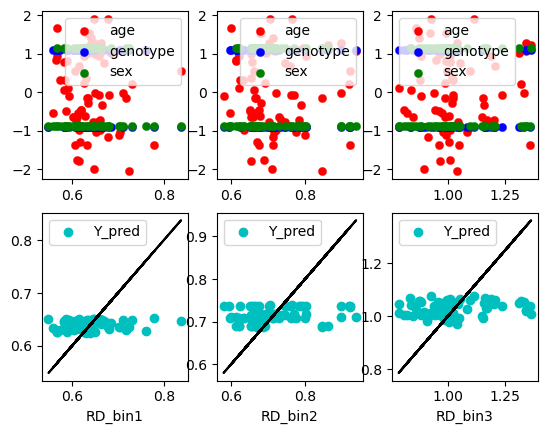

lh_BA1_exvivo
Weights:
[[-0.00146884 -0.00681615 -0.00549765]
 [ 0.00798501 -0.0116494  -0.01009939]
 [ 0.0326874  -0.01915013  0.01037331]]
MSE:
0.004733305864075253
R2:
0.09247827639949784


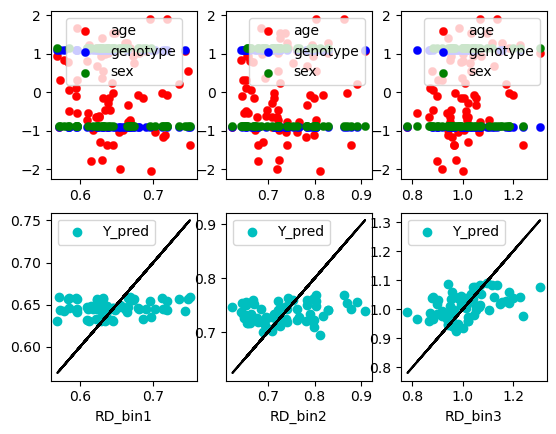

lh_BA2_exvivo_thresh
Weights:
[[-0.00035033 -0.00746388  0.01002003]
 [ 0.00506288 -0.01357309  0.01660583]
 [ 0.03664749 -0.01548629  0.067543  ]]
MSE:
0.005226331284708453
R2:
0.2070957377483664


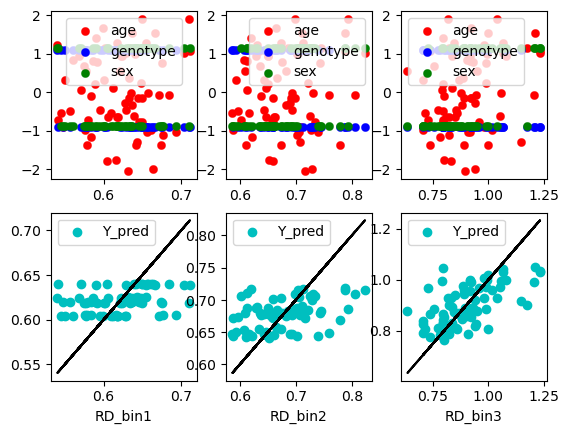

lh_BA2_exvivo
Weights:
[[-0.00112932 -0.00506936 -0.00390017]
 [ 0.00832012 -0.0088045  -0.00801091]
 [ 0.04185239 -0.01208048  0.01664766]]
MSE:
0.003396922812617012
R2:
0.12696997619577888


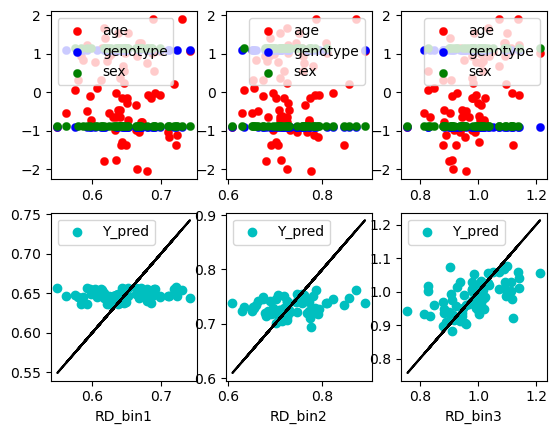

lh_BA3a_exvivo_thresh
Weights:
[[-0.0082884  -0.00771814 -0.01109626]
 [ 0.00518831 -0.00941205 -0.00700651]
 [ 0.05621636 -0.01422057  0.02288243]]
MSE:
0.006873967764000337
R2:
0.11947741883455983


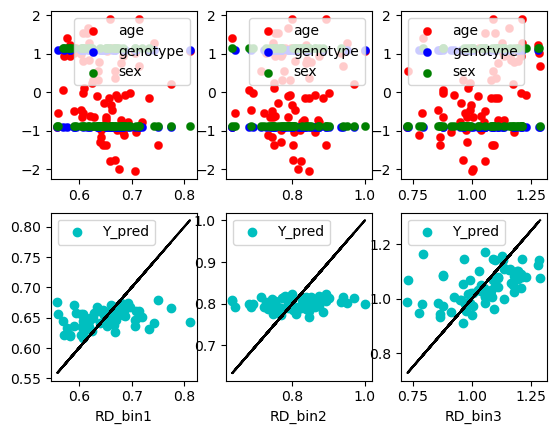

lh_BA3a_exvivo
Weights:
[[-0.00530349 -0.00387541 -0.0150766 ]
 [ 0.00482634 -0.00476932 -0.01457823]
 [ 0.05505592 -0.01393631  0.01512941]]
MSE:
0.00449899708295239
R2:
0.16720329906403342


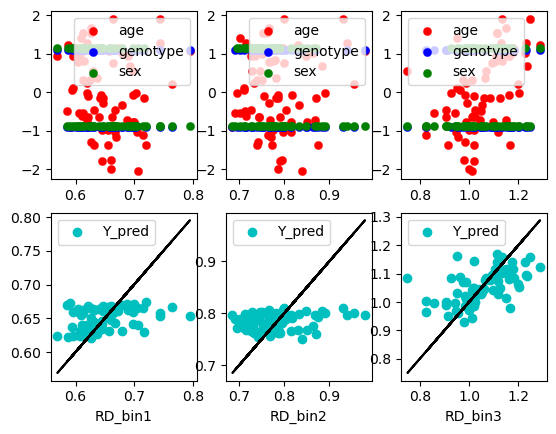

lh_BA3b_exvivo_thresh
Weights:
[[ 0.00241141 -0.00137317 -0.04022847]
 [ 0.02407539  0.00138464 -0.04974481]
 [ 0.08461263 -0.00660859 -0.02627302]]
MSE:
0.021652104373568855
R2:
0.1577072709046469


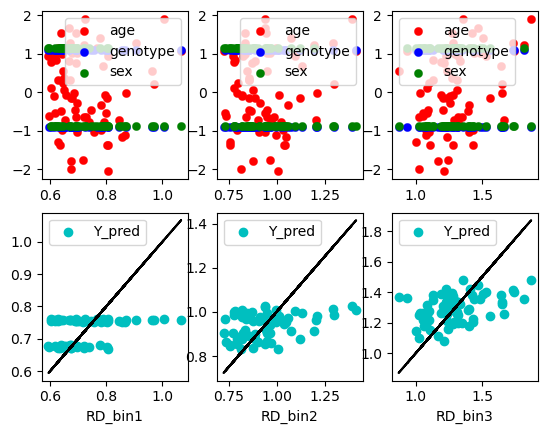

lh_BA3b_exvivo
Weights:
[[-0.00232193 -0.00269182 -0.0208869 ]
 [ 0.01130832 -0.00441796 -0.02838154]
 [ 0.05372369 -0.01147001 -0.0136389 ]]
MSE:
0.007953457419453157
R2:
0.14413701035437987


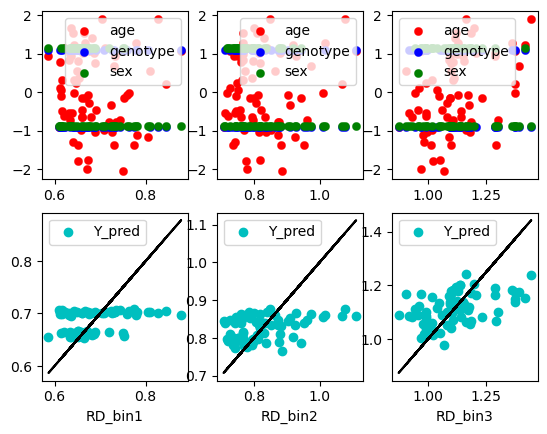

lh_BA4a_exvivo_thresh
Weights:
[[-0.00032533 -0.00801943  0.00181091]
 [ 0.00394321 -0.0103854   0.00304645]
 [ 0.03982297 -0.02576951  0.04547836]]
MSE:
0.004116747517413803
R2:
0.1539722653317224


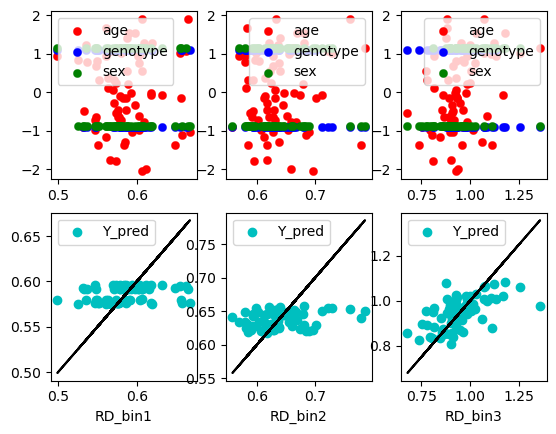

lh_BA4a_exvivo
Weights:
[[-0.00197242 -0.00792469  0.00141756]
 [ 0.00031717 -0.00864751  0.00093932]
 [ 0.02422513 -0.02377451  0.02847702]]
MSE:
0.0033718986422299206
R2:
0.11009771345447021


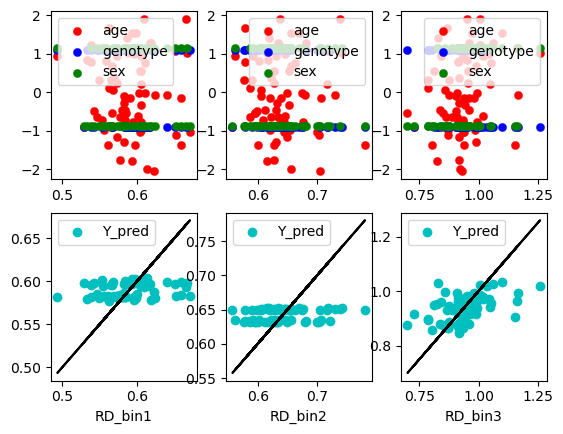

lh_BA4p_exvivo_thresh
Weights:
[[-0.00311647 -0.00659672  0.0029012 ]
 [-0.00416315 -0.00673424  0.00745369]
 [ 0.04230003 -0.01854012  0.05432486]]
MSE:
0.004324411341958286
R2:
0.15638694564498123


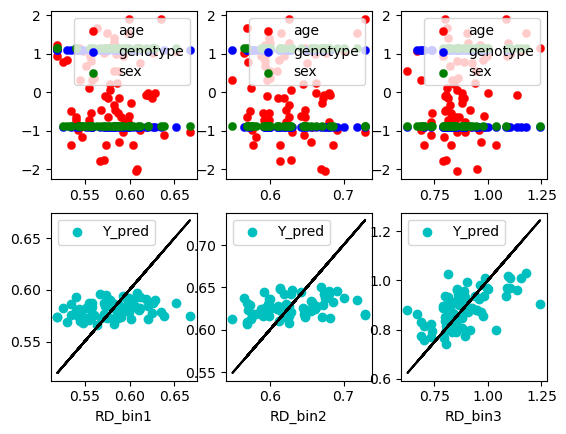

lh_BA4p_exvivo
Weights:
[[-0.00378264 -0.00812357  0.00230733]
 [-0.00193747 -0.01009441  0.00560466]
 [ 0.03793956 -0.0225226   0.05130956]]
MSE:
0.004264355148376802
R2:
0.16002040850407162


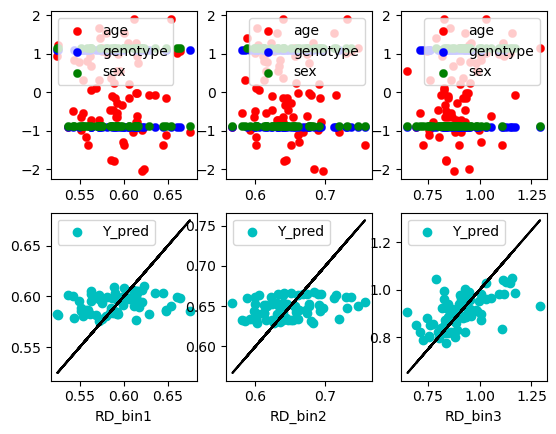

lh_BA6_exvivo_thresh
Weights:
[[-0.00281922 -0.00827028 -0.00094196]
 [-0.00047534 -0.01047491 -0.00064305]
 [ 0.02174601 -0.02126224  0.00880349]]
MSE:
0.003498580428050715
R2:
0.08110778838979753


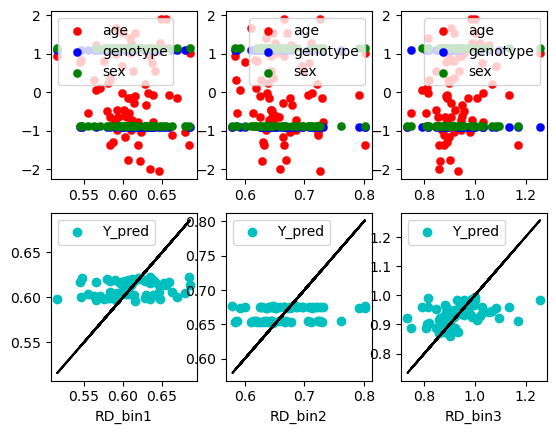

lh_BA6_exvivo
Weights:
[[-0.0023512  -0.00780537 -0.0019011 ]
 [ 0.00237959 -0.01031521 -0.00084105]
 [ 0.03119426 -0.01813944  0.00975177]]
MSE:
0.0024336013874687035
R2:
0.12587743895034195


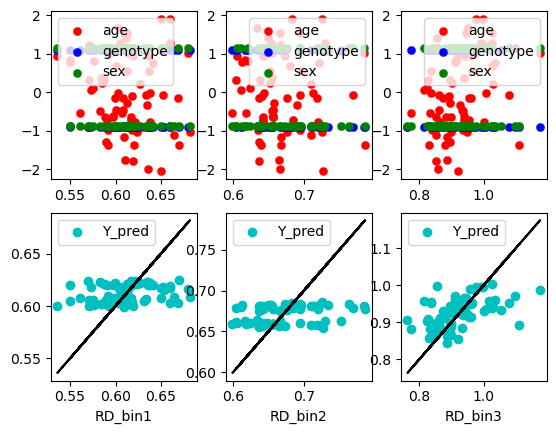

lh_BA44_exvivo_thresh
Weights:
[[-0.00454633 -0.00280608 -0.00347639]
 [ 0.00757483 -0.00567149 -0.01063434]
 [ 0.0503481   0.00243273 -0.0081502 ]]
MSE:
0.0024147290509054873
R2:
0.17061825217599816


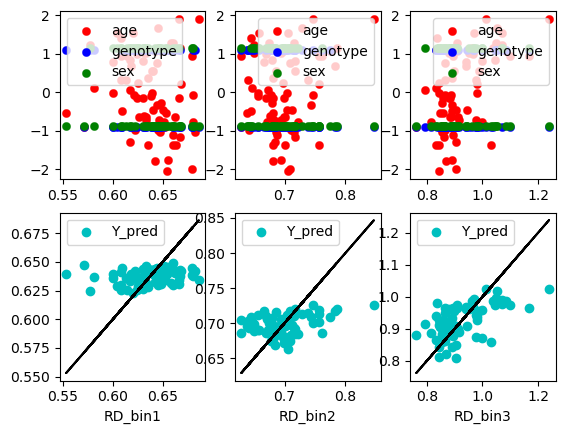

lh_BA44_exvivo
Weights:
[[-0.00425356 -0.00349965 -0.00311952]
 [ 0.00655837 -0.00566165 -0.00880521]
 [ 0.0519384  -0.00083502 -0.00530299]]
MSE:
0.0019474733477571964
R2:
0.1921237935344038


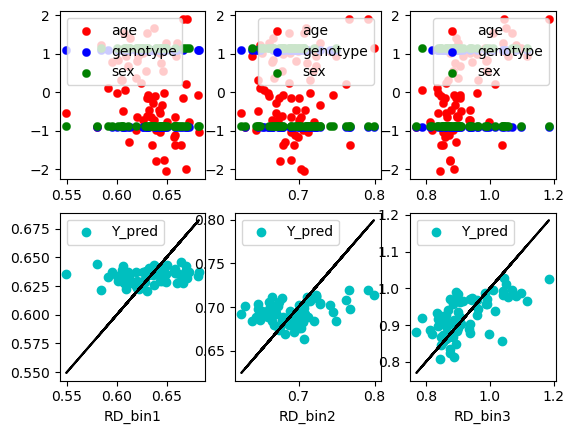

lh_BA45_exvivo_thresh
Weights:
[[-0.00063353 -0.00422153 -0.00502966]
 [ 0.01117094 -0.00131902 -0.01325486]
 [ 0.04862365  0.00886406 -0.00708663]]
MSE:
0.0033229831857712147
R2:
0.13929344965172222


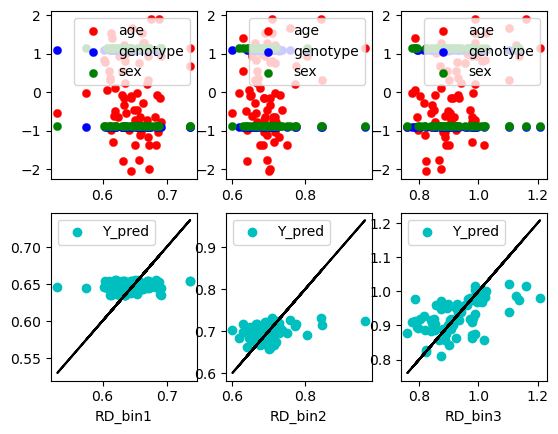

lh_BA45_exvivo
Weights:
[[-0.00190541 -0.00289437 -0.00458958]
 [ 0.00791764 -0.0031732  -0.0095077 ]
 [ 0.0454756   0.00498788  0.00120317]]
MSE:
0.0019578883350722743
R2:
0.16627532635557582


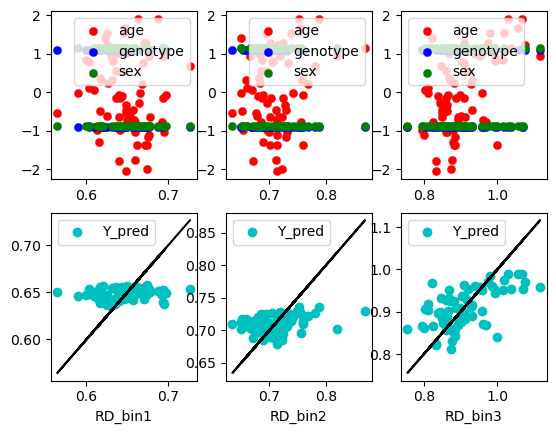

lh_cortex
Weights:
[[ 0.00400149 -0.00174106 -0.00163501]
 [ 0.01301495 -0.00297451  0.0005447 ]
 [ 0.0485778  -0.0052297   0.01331194]]
MSE:
0.0010786245058944542
R2:
0.2696532700217179


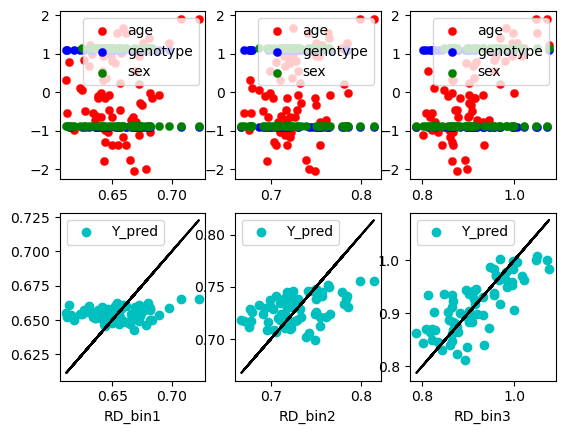

lh_cortex+hipamyg
Weights:
[[ 0.00380734 -0.00175083 -0.00173654]
 [ 0.01283291 -0.00295644  0.00048192]
 [ 0.04823476 -0.00516128  0.01324149]]
MSE:
0.0010596291362179767
R2:
0.2688451444187047


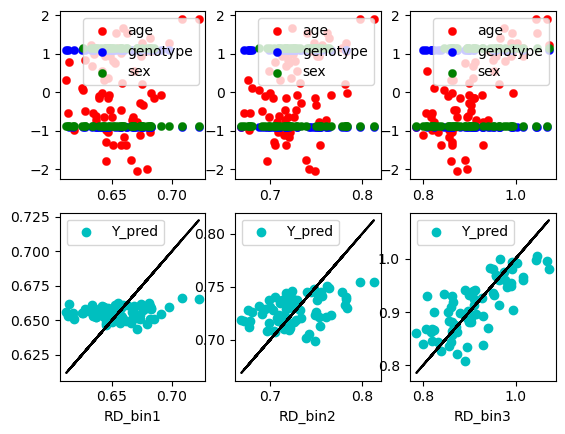

lh_entorhinal_exvivo_thresh
Weights:
[[ 0.00029649 -0.00036613 -0.01424971]
 [ 0.0179777  -0.00336799 -0.01493978]
 [ 0.05477841 -0.00733773 -0.00987522]]
MSE:
0.007099884644668929
R2:
0.12162013492097352


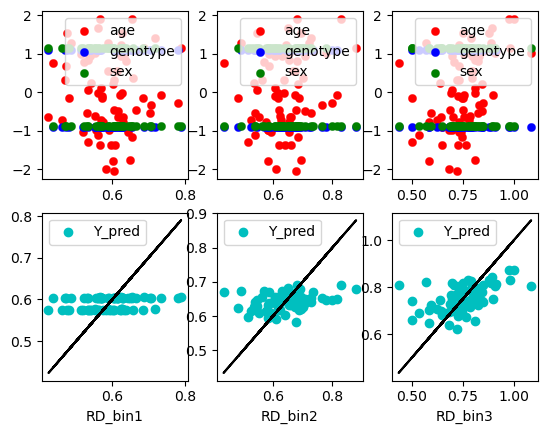

lh_entorhinal_exvivo
Weights:
[[ 0.00414236 -0.00418079 -0.01371942]
 [ 0.01889283 -0.0050024  -0.010977  ]
 [ 0.0443431  -0.00493021 -0.00984051]]
MSE:
0.003661070704781969
R2:
0.1720314887451263


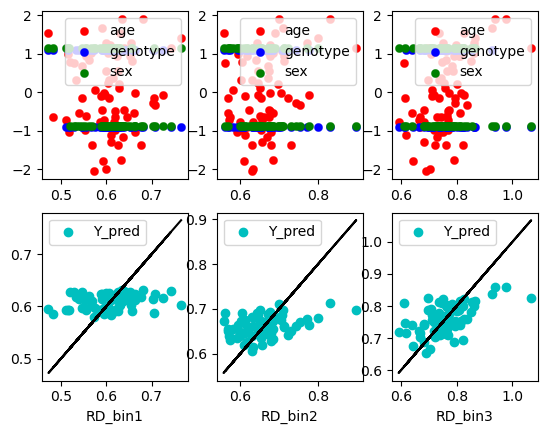

lh_FG1_mpm_vpnl
Weights:
[[ 0.00694127  0.00170329 -0.00232709]
 [ 0.02528655  0.00202774  0.00737817]
 [ 0.05967529  0.00512353  0.01278374]]
MSE:
0.004237166143493786
R2:
0.17964114300543396


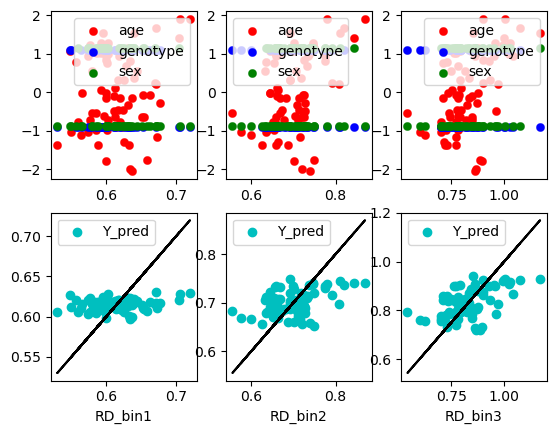

lh_FG2_mpm_vpnl
Weights:
[[ 0.00797861  0.00558632 -0.0007123 ]
 [ 0.0244089   0.00508613  0.00420142]
 [ 0.057849    0.00500917  0.01078922]]
MSE:
0.003434192790417958
R2:
0.19906454932875076


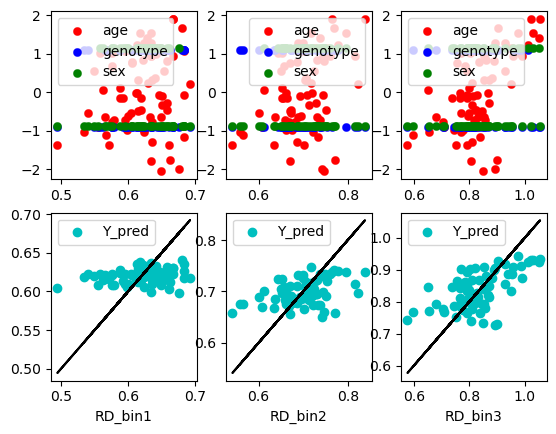

lh_FG3_mpm_vpnl
Weights:
[[ 0.00260951 -0.00254007 -0.00294135]
 [ 0.02394634 -0.0023928   0.00511507]
 [ 0.07697534  0.00278689  0.01513781]]
MSE:
0.002259971169769431
R2:
0.29433197410191964


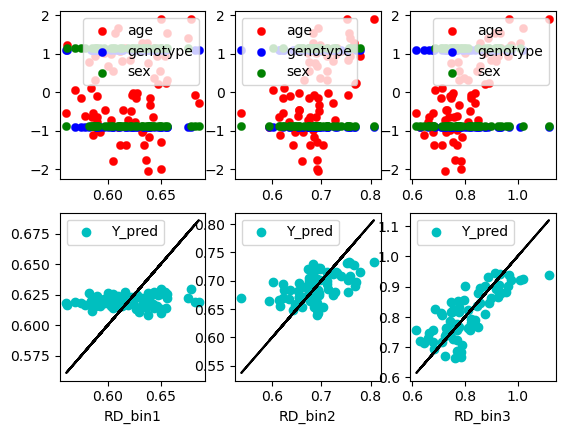

lh_FG4_mpm_vpnl
Weights:
[[ 0.00765966  0.00091579  0.00034896]
 [ 0.01838031  0.00319782  0.00582597]
 [ 0.05945797 -0.00016793  0.01282555]]
MSE:
0.002567957240375012
R2:
0.22075967781855052


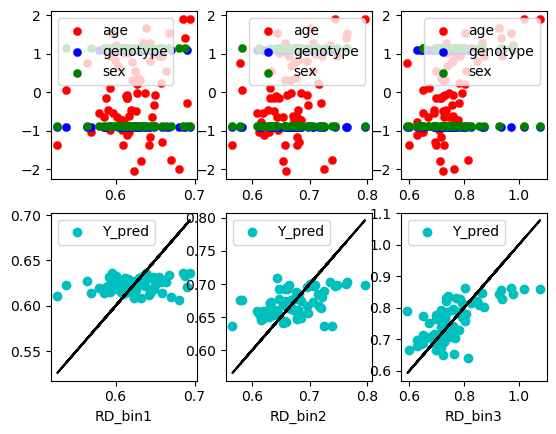

lh_hOc1_mpm_vpnl
Weights:
[[ 1.96345849e-02 -2.54954049e-03 -4.18392142e-03]
 [ 3.53745260e-02 -5.81823377e-03  1.34763090e-02]
 [ 5.94250457e-02 -8.88513908e-05  3.87433427e-02]]
MSE:
0.0035972343430231016
R2:
0.3252123479410218


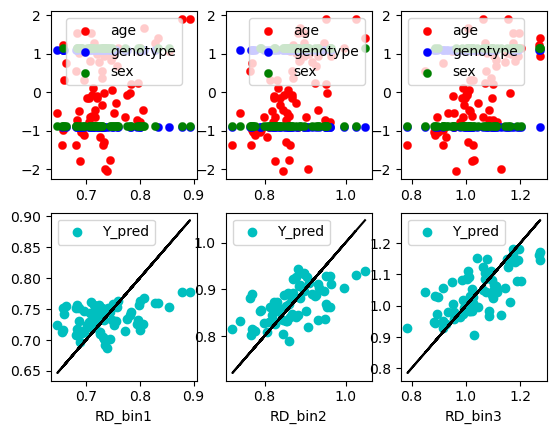

lh_hOc2_mpm_vpnl
Weights:
[[ 0.01380668 -0.00149755  0.00044683]
 [ 0.02695212 -0.00534506  0.01712294]
 [ 0.05175305 -0.00463746  0.0472746 ]]
MSE:
0.003958146569903426
R2:
0.2568676744877368


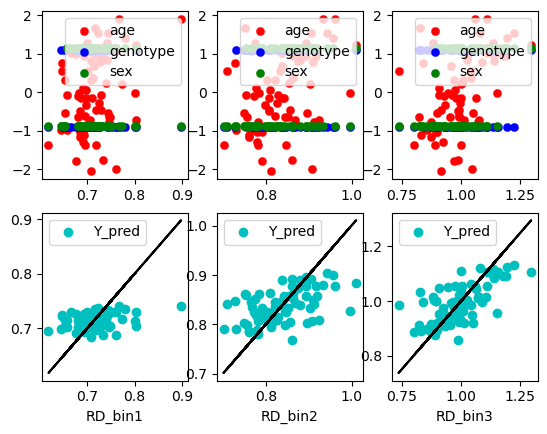

lh_hOc3v_mpm_vpnl
Weights:
[[0.01978804 0.0077657  0.00331045]
 [0.02430134 0.00593748 0.00973745]
 [0.04261205 0.0050209  0.02264771]]
MSE:
0.0054618974023312354
R2:
0.15862327274386076


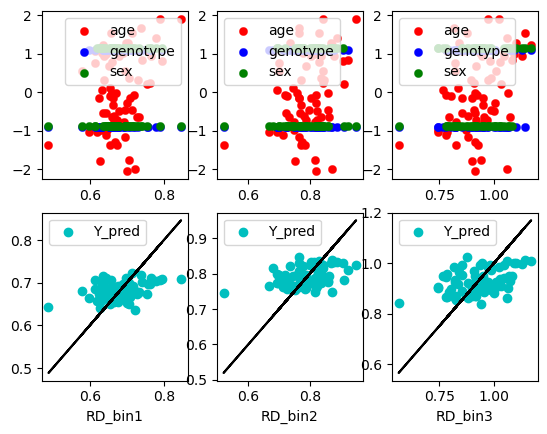

lh_hOc4v_mpm_vpnl
Weights:
[[0.0184474  0.00214063 0.00032229]
 [0.03363561 0.00151104 0.01558432]
 [0.05817253 0.00259421 0.02680999]]
MSE:
0.004600039412385965
R2:
0.24948943894433254


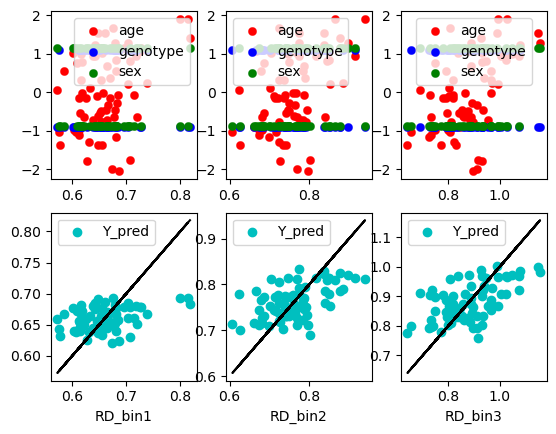

lh_MT_exvivo_thresh
Weights:
[[ 0.00159161  0.00503854 -0.00070705]
 [ 0.01336471 -0.00023378  0.00293149]
 [ 0.05329504  0.0001185   0.02858746]]
MSE:
0.005041905572203041
R2:
0.11099302210559485


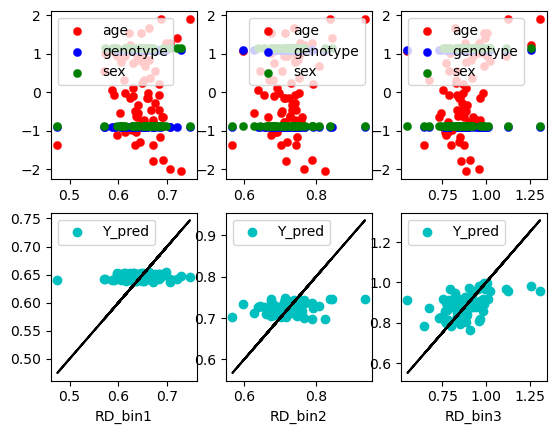

lh_MT_exvivo
Weights:
[[ 0.00468565  0.00554277 -0.00253587]
 [ 0.01516733  0.00154105 -0.00161427]
 [ 0.05531827  0.00058281  0.01793596]]
MSE:
0.0034372236164797424
R2:
0.15647688993565914


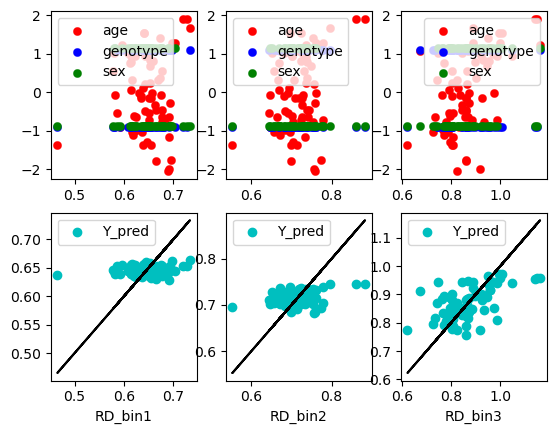

lh_nofix_cortex
Weights:
[[ 0.00839804 -0.00199704 -0.00196405]
 [ 0.0168402  -0.0031761   0.00027032]
 [ 0.05003032 -0.00520897  0.01278889]]
MSE:
0.0011107382594547173
R2:
0.32809038437460863


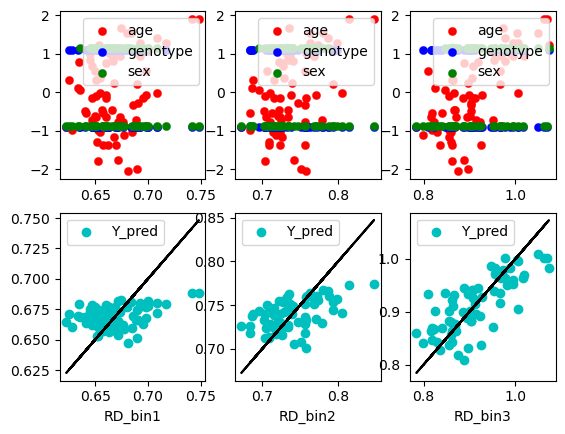

lh_perirhinal_exvivo_thresh
Weights:
[[ 0.00524156 -0.00488418 -0.01074083]
 [ 0.00903875  0.00060683 -0.00558347]
 [ 0.02529793  0.00282101 -0.00469866]]
MSE:
0.0034928928992417267
R2:
0.07606049966956452


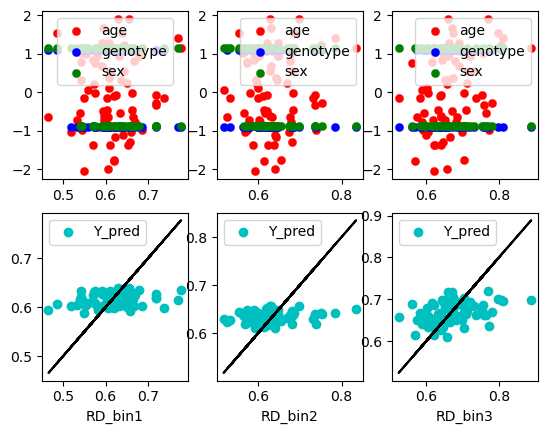

lh_perirhinal_exvivo
Weights:
[[ 0.00449588 -0.00585659 -0.01144588]
 [ 0.01180672 -0.00480517 -0.00986898]
 [ 0.0311806  -0.00527049 -0.00758454]]
MSE:
0.0033038755435102923
R2:
0.11662880097225863


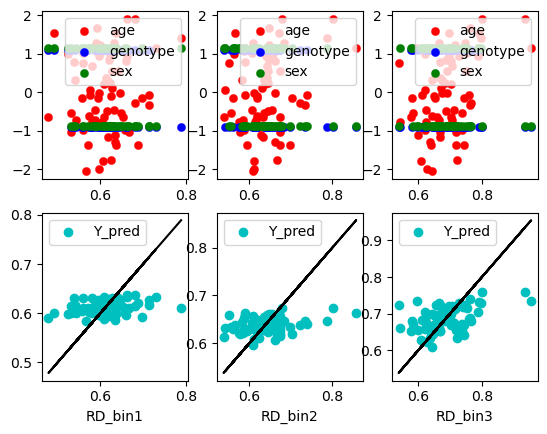

lh_V1_exvivo_thresh
Weights:
[[ 0.01863972 -0.00190355 -0.00716565]
 [ 0.03434526 -0.00590818  0.01036104]
 [ 0.05893238 -0.00095052  0.03684544]]
MSE:
0.0037838771659409742
R2:
0.30367904912319016


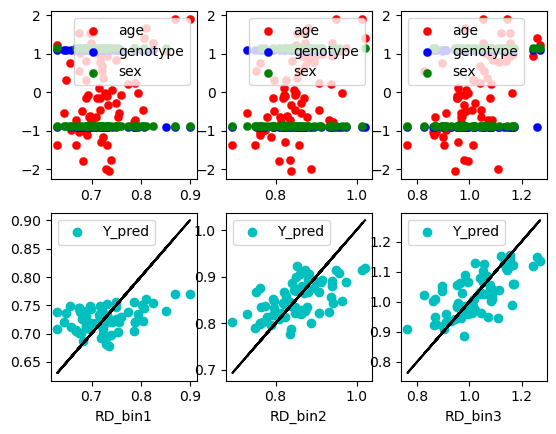

lh_V1_exvivo
Weights:
[[ 0.01701865 -0.00203064 -0.00428369]
 [ 0.03206973 -0.00491565  0.01287892]
 [ 0.05516731 -0.00038069  0.0399015 ]]
MSE:
0.003697311345114787
R2:
0.28923778791144455


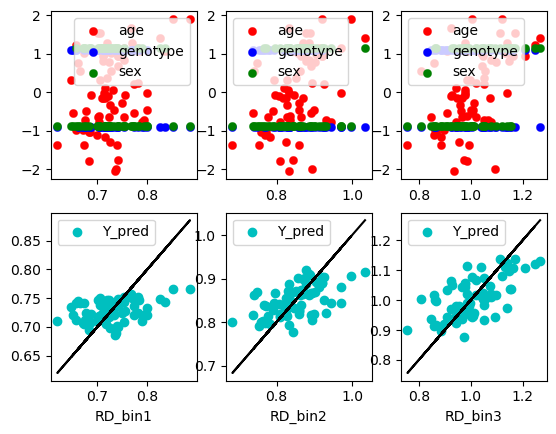

lh_V2_exvivo_thresh
Weights:
[[ 0.01736285 -0.00059018  0.00604089]
 [ 0.0293981  -0.00301905  0.02245398]
 [ 0.04926937 -0.00156006  0.04651753]]
MSE:
0.004293491238208347
R2:
0.2737297843175301


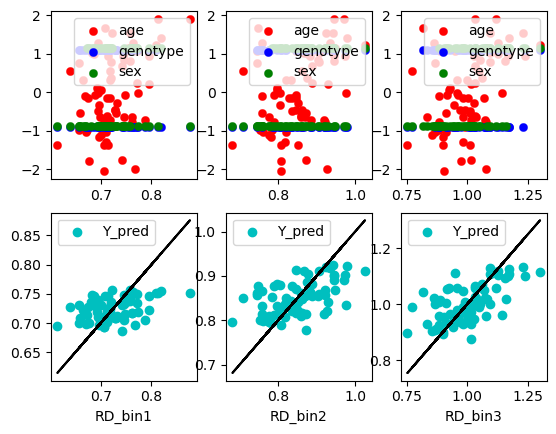

lh_V2_exvivo
Weights:
[[ 0.01640745  0.00047145  0.00076725]
 [ 0.02882054 -0.00249395  0.01458273]
 [ 0.05362291 -0.00166144  0.03678066]]
MSE:
0.003210176895648703
R2:
0.29332026020781427


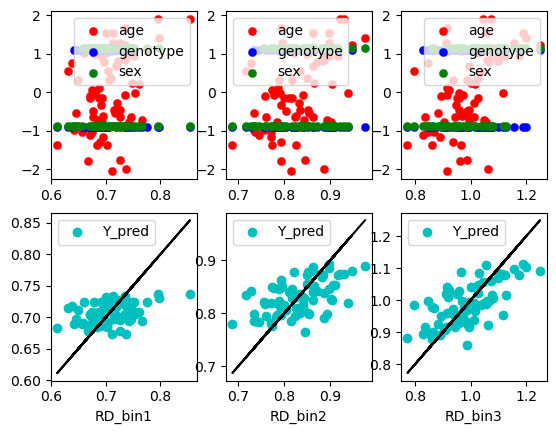

In [8]:
from sklearn.metrics import r2_score
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y = left_dic[region]
    linear_model = LinearRegression()
    linear_model.fit(X, Y)
    r2 = linear_model.score(X, Y)
    weights = linear_model.coef_
    Y_pred = linear_model.predict(X)
    mse = np.mean((Y_pred - Y) ** 2)
    print('Weights:')
    print(weights)
    print('MSE:')
    print(mse)
    print('R2:')
    print(r2)
    plt.subplot(2, 3, 1)
    plt.scatter(Y[:,0], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,0], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,0], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 4)
    plt.scatter(Y[:,0], Y_pred[:,0], label='Y_pred', color='c')
    plt.plot(Y[:,0], Y[:,0], color='k')
    plt.legend()
    plt.xlabel('RD_bin1')
    plt.subplot(2, 3, 2)
    plt.scatter(Y[:,1], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,1], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,1], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 5)
    plt.scatter(Y[:,1], Y_pred[:,1], label='Y_pred', color='c')
    plt.plot(Y[:,1], Y[:,1], color='k')
    plt.legend()
    plt.xlabel('RD_bin2')
    plt.subplot(2, 3, 3)
    plt.scatter(Y[:,2], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,2], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,2], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 6)
    plt.scatter(Y[:,2], Y_pred[:,2], label='Y_pred', color='c')
    plt.plot(Y[:,2], Y[:,2], color='k')
    plt.legend()
    plt.xlabel('RD_bin3')
    plt.show()



In [9]:
# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    age_column = np.append(age_column, age)

age_column = age_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Combine features
X = age_column
print(X)

[[63.        ]
 [20.21      ]
 [37.        ]
 [47.        ]
 [68.        ]
 [44.        ]
 [66.7       ]
 [25.        ]
 [31.        ]
 [60.66      ]
 [54.        ]
 [42.62      ]
 [41.        ]
 [78.13      ]
 [82.        ]
 [56.        ]
 [45.        ]
 [21.        ]
 [31.        ]
 [38.        ]
 [65.41      ]
 [31.        ]
 [42.        ]
 [64.        ]
 [67.        ]
 [61.        ]
 [36.92777778]
 [71.26      ]
 [40.        ]
 [44.        ]
 [76.        ]
 [81.65      ]
 [36.        ]
 [67.86      ]
 [72.        ]
 [55.4       ]
 [44.78      ]
 [76.        ]
 [52.        ]
 [57.        ]
 [41.        ]
 [50.        ]
 [32.        ]
 [34.        ]
 [38.        ]
 [48.        ]
 [64.45      ]
 [53.        ]
 [65.        ]
 [45.        ]
 [42.        ]
 [51.        ]
 [58.        ]
 [50.88      ]
 [57.        ]
 [35.        ]
 [50.        ]
 [42.        ]
 [70.        ]
 [70.        ]
 [36.        ]
 [51.        ]
 [68.        ]
 [72.        ]
 [50.        ]
 [67.04      ]
 [69.     

lh_BA1_exvivo_thresh
Weights:
[[-0.00013109]] [[0.00015633]] [[0.0008958]]
MSE:
0.0026074501507602696 0.007463040664760053 0.02026922087539191
R2:
0.001587603210871591 0.0007895142467316818 0.009461632672752684


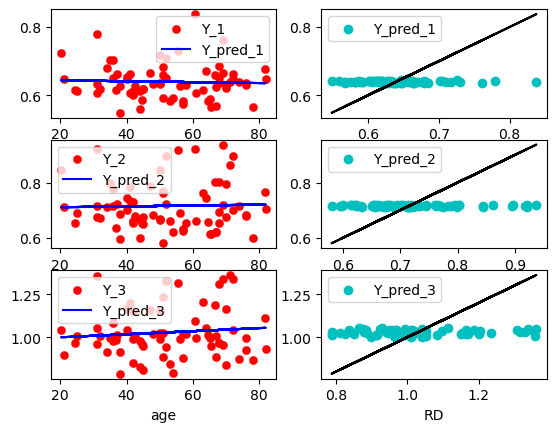

lh_BA1_exvivo
Weights:
[[-4.60249617e-05]] [[0.00059727]] [[0.00223147]]
MSE:
0.0019407426248867913 0.00432976254633848 0.008717921487106511
R2:
0.0002632790055437928 0.019491584422430375 0.12111846047881647


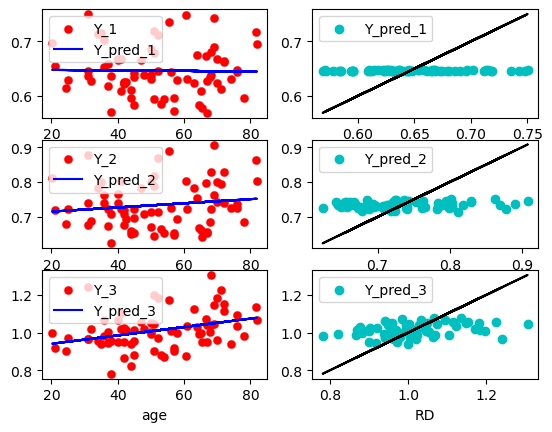

lh_BA2_exvivo_thresh
Weights:
[[2.48302317e-05]] [[0.00041269]] [[0.00244084]]
MSE:
0.0017329299041675425 0.0030985697277299083 0.016444650139504267
R2:
8.583312532883802e-05 0.013088210812702727 0.08038417071723702


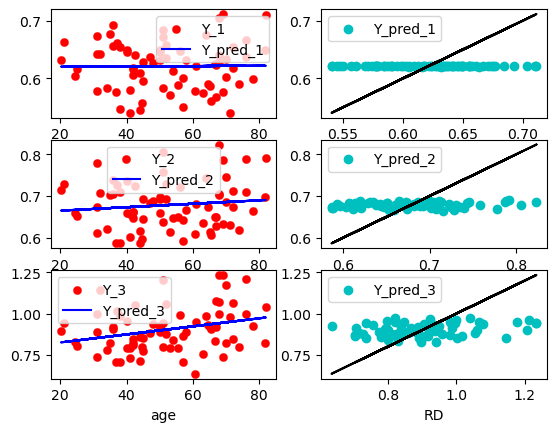

lh_BA2_exvivo
Weights:
[[-3.66737506e-05]] [[0.00059866]] [[0.00277095]]
MSE:
0.0016624367053673854 0.002974837690076554 0.006171570315842699
R2:
0.00019516072719893973 0.028246935054770272 0.23087255986399313


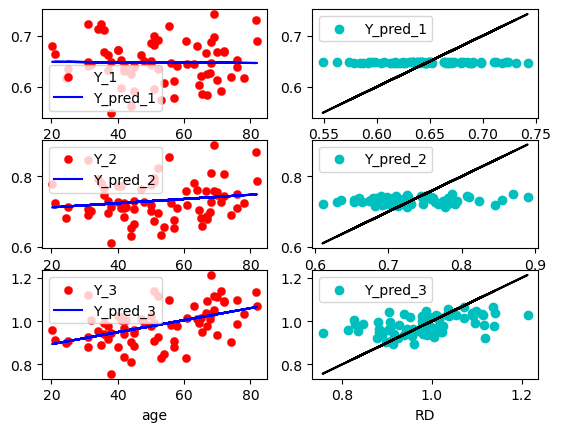

lh_BA3a_exvivo_thresh
Weights:
[[-0.00047689]] [[0.00040083]] [[0.00370807]]
MSE:
0.0024570426973416753 0.005394710143592117 0.01383624139671833
R2:
0.021844297607313434 0.007134373252631332 0.19339660959237848


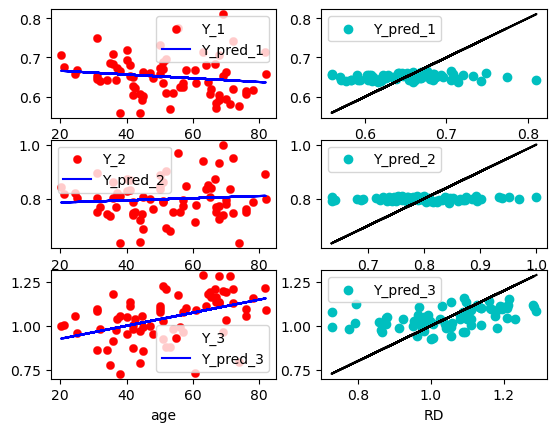

lh_BA3a_exvivo
Weights:
[[-0.00030954]] [[0.00034853]] [[0.00363421]]
MSE:
0.0020603768304852505 0.003964211054607949 0.008381859569765556
R2:
0.011095686953234152 0.007339173698503343 0.2754572191556587


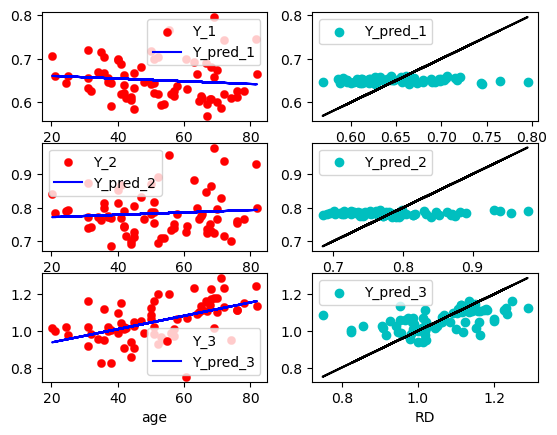

lh_BA3b_exvivo_thresh
Weights:
[[0.00017909]] [[0.00155837]] [[0.00550186]]
MSE:
0.010119614064027158 0.022624973124233973 0.0370197110126016
R2:
0.00076407316310656 0.025244240288408326 0.1647783063691869


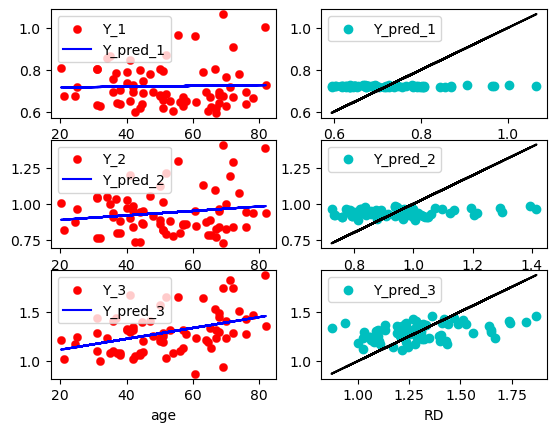

lh_BA3b_exvivo
Weights:
[[-0.00012359]] [[0.0007684]] [[0.00354193]]
MSE:
0.0037661032145191436 0.008093827339370698 0.01353834286014314
R2:
0.0009775613718995269 0.017296377554437026 0.1827238786937191


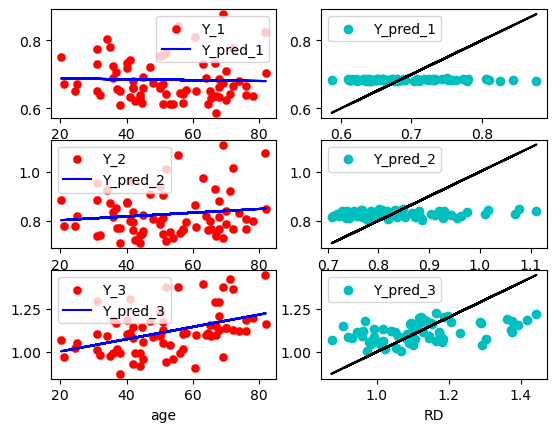

lh_BA4a_exvivo_thresh
Weights:
[[3.31855872e-05]] [[0.00032371]] [[0.00272345]]
MSE:
0.0011866691774413084 0.002168149416714609 0.01207018514767464
R2:
0.00022386374989846747 0.011526396174011633 0.12912001452692567


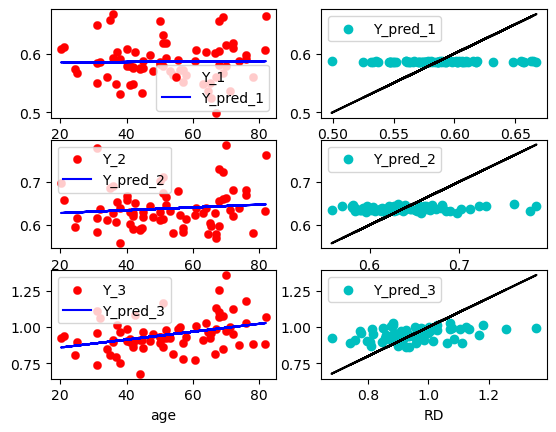

lh_BA4a_exvivo
Weights:
[[-7.33582093e-05]] [[7.91528367e-05]] [[0.00171176]]
MSE:
0.0011799395016293642 0.00204464932052088 0.008495374738733593
R2:
0.0010991873625032511 0.0007387624839799711 0.07682412250249693


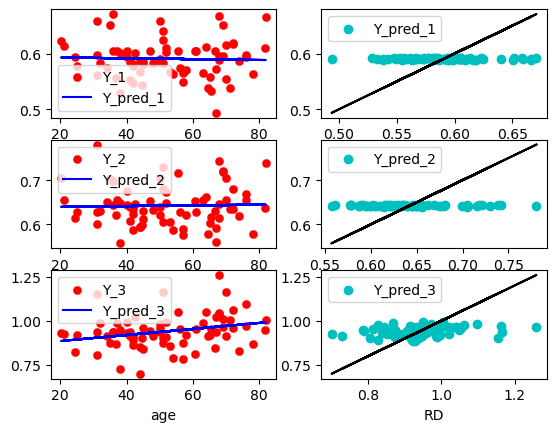

lh_BA4p_exvivo_thresh
Weights:
[[-0.00015662]] [[-0.0002247]] [[0.00283035]]
MSE:
0.0009756219315660101 0.001735026975490789 0.013853121066824998
R2:
0.006029426671139926 0.006972078178228869 0.12243966834939557


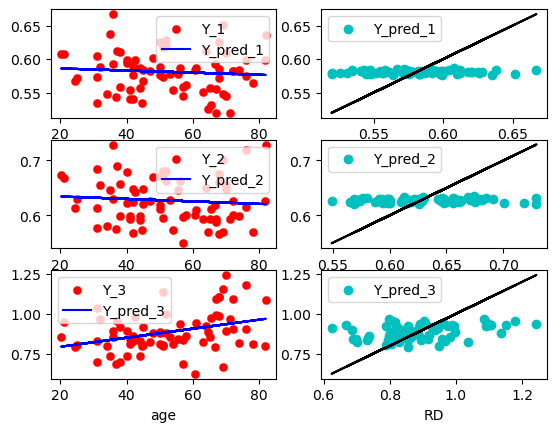

lh_BA4p_exvivo
Weights:
[[-0.00018886]] [[-5.77922279e-05]] [[0.00257792]]
MSE:
0.001065272275197414 0.001791874654861639 0.013441722012078734
R2:
0.008013744026755809 0.00044951856951613856 0.10657451765687409


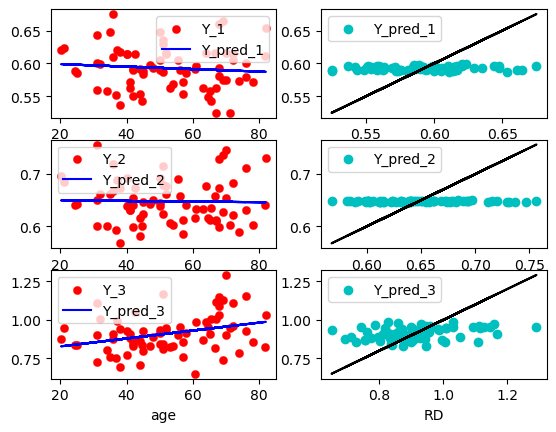

lh_BA6_exvivo_thresh
Weights:
[[-0.00012467]] [[4.11837746e-05]] [[0.00154206]]
MSE:
0.001149017288935397 0.002358561113397934 0.0077137651939208985
R2:
0.0032528386279155885 0.00017347682828816602 0.06922972615174494


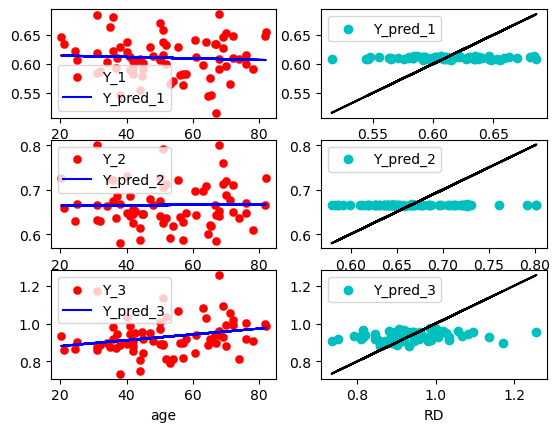

lh_BA6_exvivo
Weights:
[[-9.73656148e-05]] [[0.00022396]] [[0.00212866]]
MSE:
0.0009694064056492729 0.0018901138181459001 0.005052525600745578
R2:
0.0023539297035739537 0.006362060595120678 0.17788808016576696


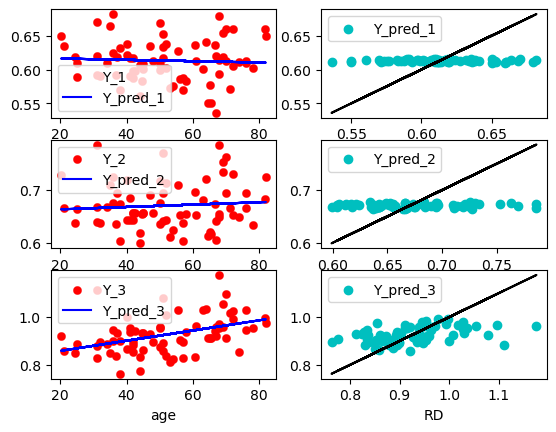

lh_BA44_exvivo_thresh
Weights:
[[-0.00027227]] [[0.00053022]] [[0.00322767]]
MSE:
0.0006957350825289992 0.001546946363666502 0.005231646065961065
R2:
0.025063605327914074 0.04200671034513592 0.3245316034211312


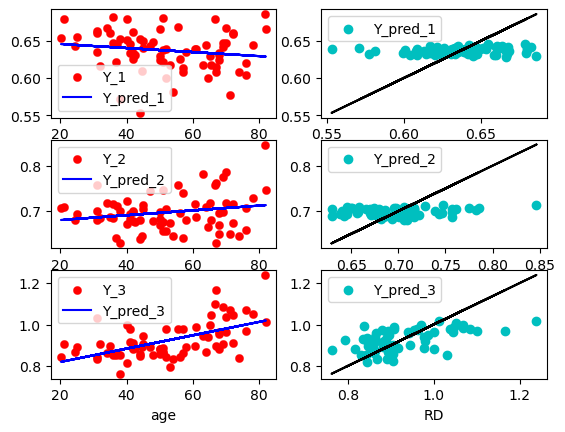

lh_BA44_exvivo
Weights:
[[-0.00024881]] [[0.00046406]] [[0.00335135]]
MSE:
0.0006156083234223959 0.0012099315635245482 0.0041678067520780765
R2:
0.02368860049666688 0.04117562090814497 0.39401131947372336


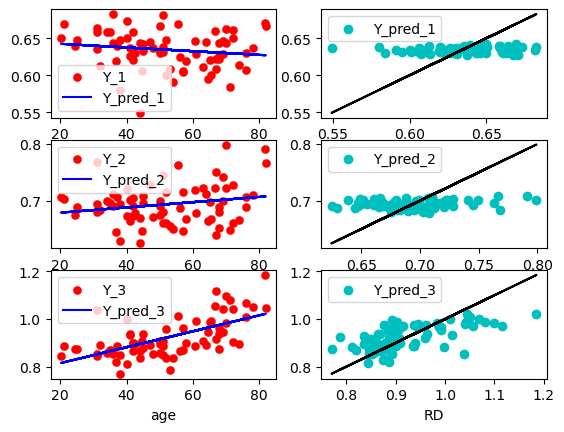

lh_BA45_exvivo_thresh
Weights:
[[-1.01407827e-05]] [[0.00073295]] [[0.00307234]]
MSE:
0.0010360886057138394 0.002893064118409107 0.006391333334584811
R2:
2.3946790166151644e-05 0.042881195071358125 0.2627189195519365


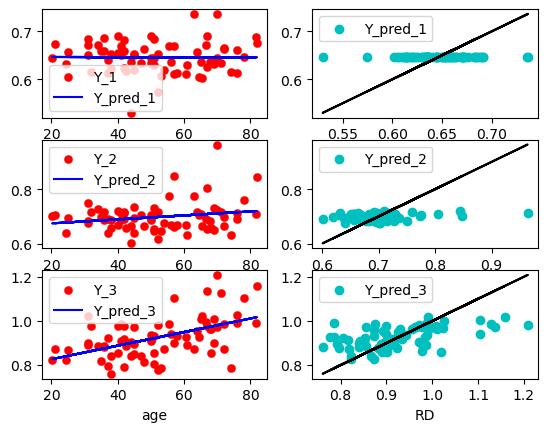

lh_BA45_exvivo
Weights:
[[-0.00010125]] [[0.00053482]] [[0.00289317]]
MSE:
0.0008096423611215135 0.001543062300303444 0.0036699160133547076
R2:
0.0030455173620701492 0.042810181152793336 0.35496543252794854


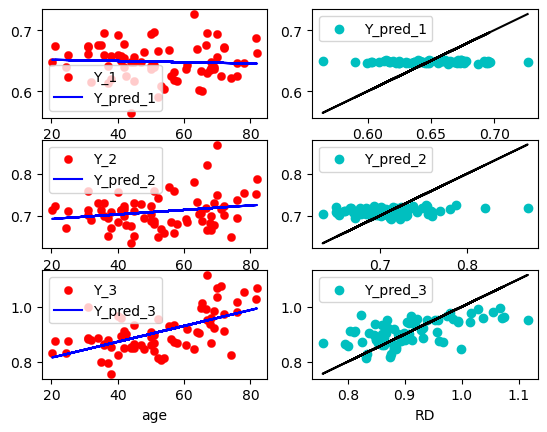

lh_cortex
Weights:
[[0.00027009]] [[0.00085801]] [[0.00315833]]
MSE:
0.0004891534016391298 0.0007904302539720908 0.0021846345708515184
R2:
0.0347328793832794 0.1834845220805893 0.5241855462865348


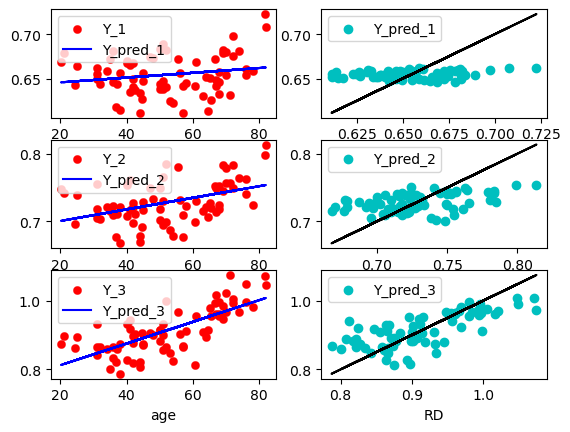

lh_cortex+hipamyg
Weights:
[[0.0002577]] [[0.00084619]] [[0.0031358]]
MSE:
0.0004791672662457071 0.0007783305827554118 0.002147137935019789
R2:
0.03235631305613329 0.181646328248123 0.5249329730550996


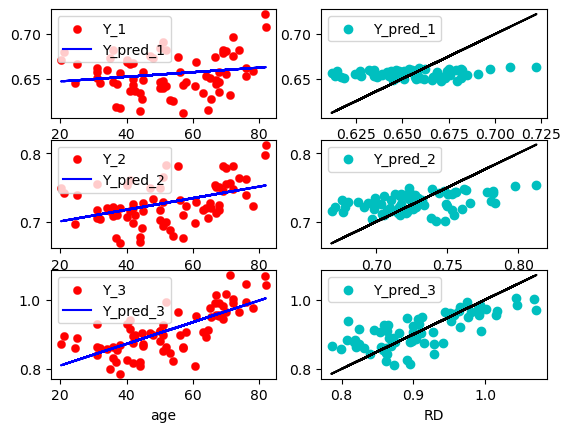

lh_entorhinal_exvivo_thresh
Weights:
[[2.67111332e-05]] [[0.00118576]] [[0.00358025]]
MSE:
0.005286947729131595 0.006182897926838539 0.010400582529636323
R2:
3.255945482938394e-05 0.052013721134525515 0.22920342738259847


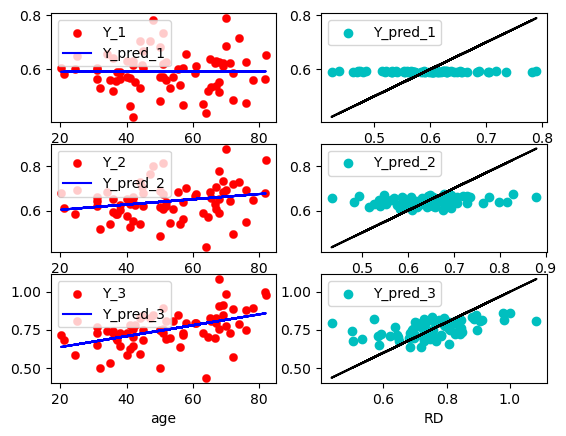

lh_entorhinal_exvivo
Weights:
[[0.00030017]] [[0.00125442]] [[0.00289198]]
MSE:
0.003179930885921811 0.0034395169030199554 0.004813297493846554
R2:
0.006790067034077141 0.09940920720846946 0.2953960014854594


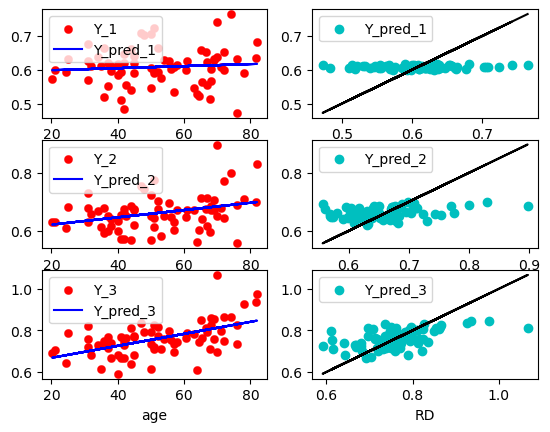

lh_FG1_mpm_vpnl
Weights:
[[0.00043607]] [[0.00161142]] [[0.00380224]]
MSE:
0.0013721167575560164 0.002739357755591436 0.008845685273914673
R2:
0.032356056208980855 0.18613642323753177 0.28280947013714186


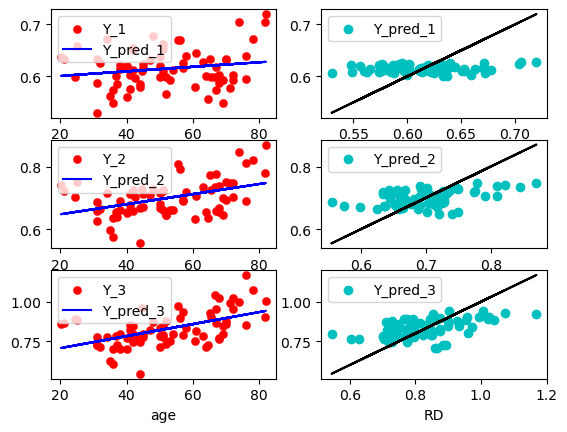

lh_FG2_mpm_vpnl
Weights:
[[0.00047575]] [[0.00153517]] [[0.00368616]]
MSE:
0.001547124026730735 0.0027425505025502703 0.006218905707623375
R2:
0.03409419800172275 0.17172802085841188 0.34519217472220165


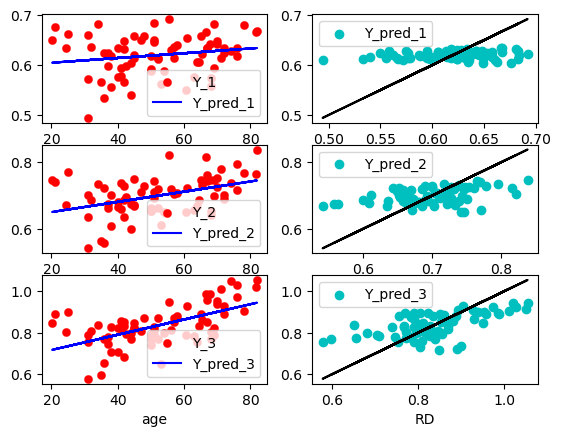

lh_FG3_mpm_vpnl
Weights:
[[0.00018641]] [[0.00155615]] [[0.00493112]]
MSE:
0.0008227667262604027 0.0017094049845799543 0.004526287040701155
R2:
0.01008675806069248 0.25473081262628927 0.5644910589334946


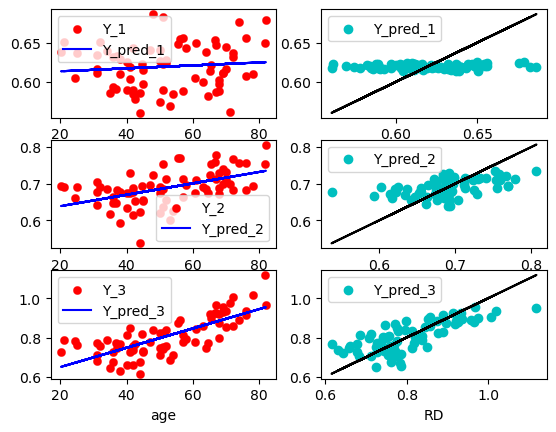

lh_FG4_mpm_vpnl
Weights:
[[0.00048674]] [[0.00115937]] [[0.00382438]]
MSE:
0.0009951142440684328 0.001611935762219079 0.005304037118215096
R2:
0.05432208013816786 0.16749205941461254 0.3995130122024635


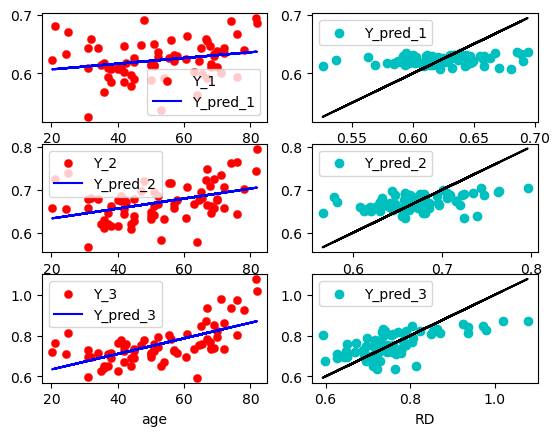

lh_hOc1_mpm_vpnl
Weights:
[[0.00128297]] [[0.00231228]] [[0.0038124]]
MSE:
0.0022607467342950975 0.00299604065463511 0.007284699468498369
R2:
0.14942070009117703 0.30097776958350453 0.3249587373012609


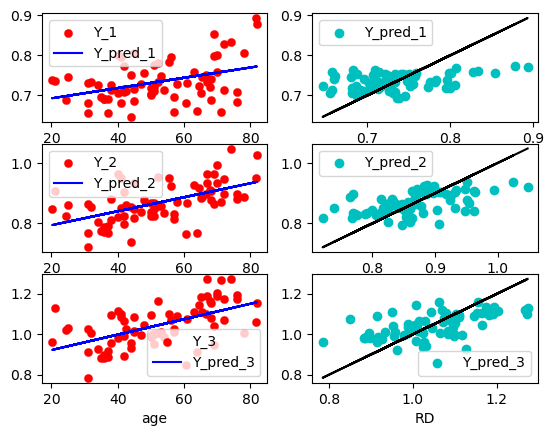

lh_hOc2_mpm_vpnl
Weights:
[[0.00089893]] [[0.00176551]] [[0.00334649]]
MSE:
0.001698228812061953 0.003718485415756082 0.009080396204667532
R2:
0.10298332835940494 0.16822496695098987 0.2293277516390162


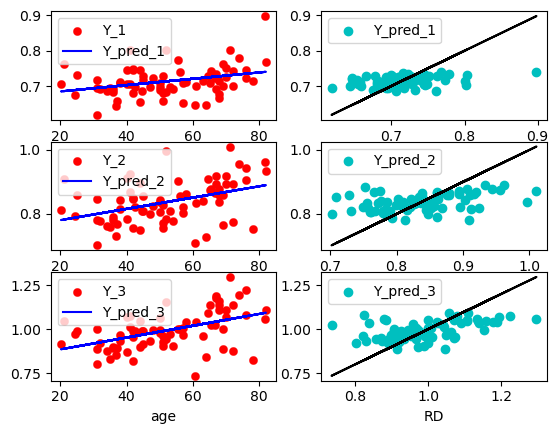

lh_hOc3v_mpm_vpnl
Weights:
[[0.0012197]] [[0.00152044]] [[0.00270088]]
MSE:
0.0025921458210939655 0.00423342611574176 0.01027113957091063
R2:
0.12162818664899389 0.11641395402008792 0.14628997768863405


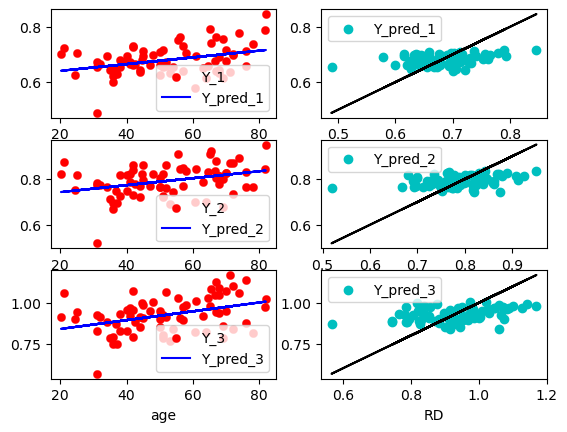

lh_hOc4v_mpm_vpnl
Weights:
[[0.00117289]] [[0.0021495]] [[0.00371773]]
MSE:
0.0020900143861767202 0.00374334874374685 0.008929047179642201
R2:
0.13704482333616474 0.22946632669840294 0.2719200821377661


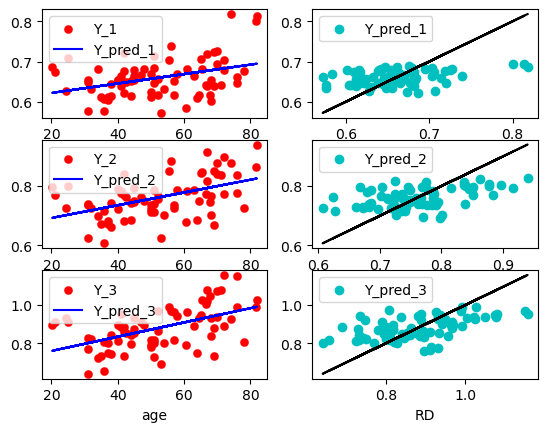

lh_MT_exvivo_thresh
Weights:
[[6.83017699e-05]] [[0.00086095]] [[0.00342]]
MSE:
0.0016759651576731141 0.002904220441264979 0.011397129012126382
R2:
0.0006711490999763425 0.05800760429079843 0.19846710824602298


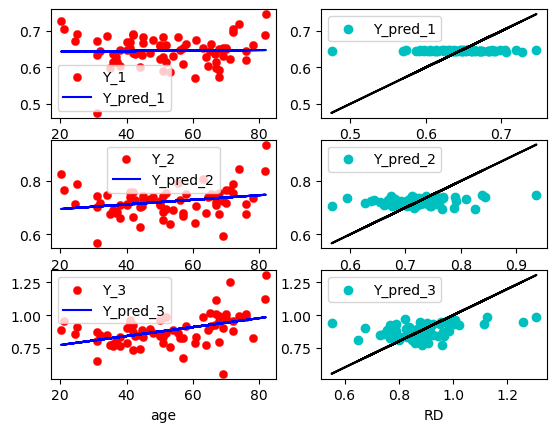

lh_MT_exvivo
Weights:
[[0.00026471]] [[0.00096651]] [[0.00355091]]
MSE:
0.0015890745177844238 0.0020706704530013774 0.007016546748371056
R2:
0.010526881904159069 0.09816185275605427 0.30244430703112024


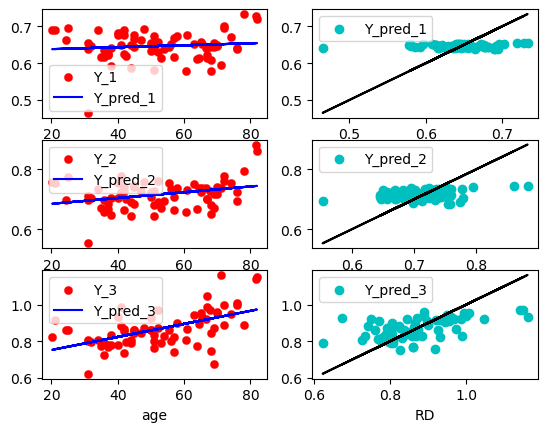

lh_nofix_cortex
Weights:
[[0.00055501]] [[0.00110575]] [[0.00325189]]
MSE:
0.0005340312173042478 0.0008464346661088259 0.0021686966090984023
R2:
0.122166234464545 0.258449553218139 0.540542011547547


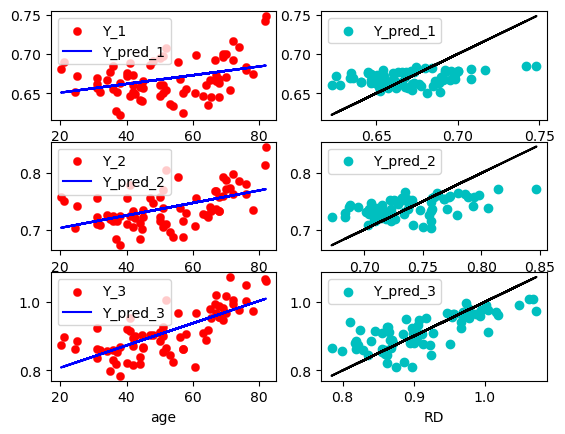

lh_perirhinal_exvivo_thresh
Weights:
[[0.00037467]] [[0.00057977]] [[0.00161107]]
MSE:
0.0034147252401887213 0.0034410605459985 0.0038184096857849952
R2:
0.009821332266232496 0.023025569928954437 0.14089796534133037


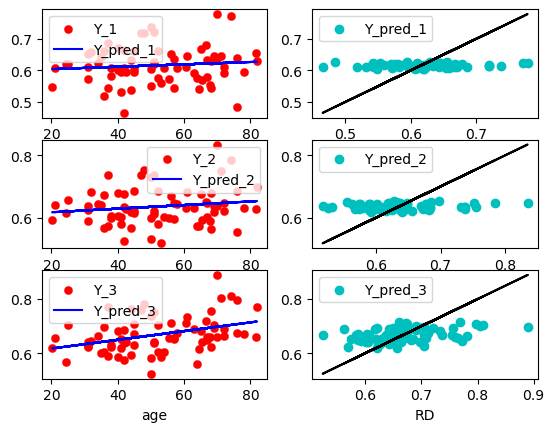

lh_perirhinal_exvivo
Weights:
[[0.00033356]] [[0.00079648]] [[0.0020461]]
MSE:
0.0028127177241627937 0.0031171754900480584 0.00433067049337279
R2:
0.009453910418133038 0.04680355049426377 0.18913109993092803


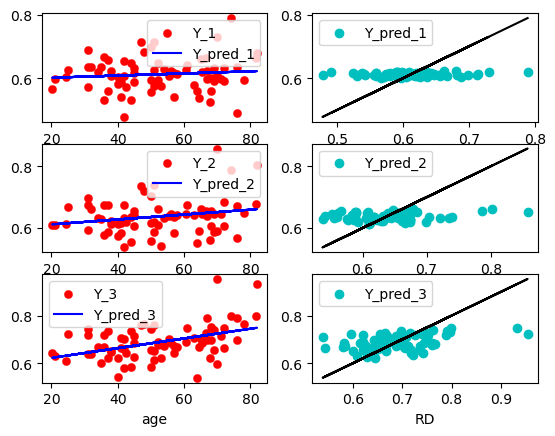

lh_V1_exvivo_thresh
Weights:
[[0.00121559]] [[0.00224775]] [[0.00378726]]
MSE:
0.0025185317411233954 0.0030040795373223127 0.007395581385680448
R2:
0.1240043781662088 0.2886533059683134 0.31877241167841197


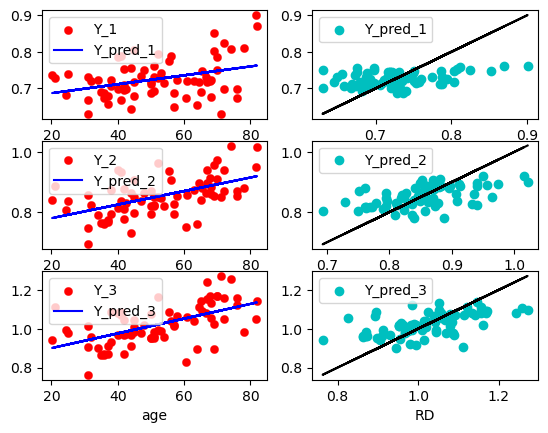

lh_V1_exvivo
Weights:
[[0.00111105]] [[0.00209357]] [[0.00353987]]
MSE:
0.002089435215822906 0.0030407115972242663 0.007775769173509661
R2:
0.12476131696364412 0.2580414191143643 0.27996194923818496


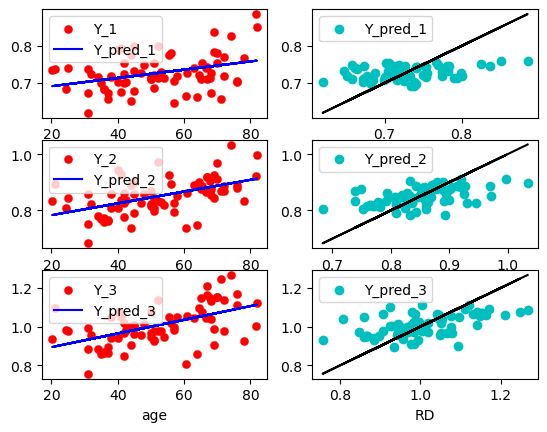

lh_V2_exvivo_thresh
Weights:
[[0.00111966]] [[0.00190517]] [[0.00316585]]
MSE:
0.0017354850366616572 0.00423314884681834 0.009647824052209025
R2:
0.14841956329659511 0.1714164941858578 0.20041373566743226


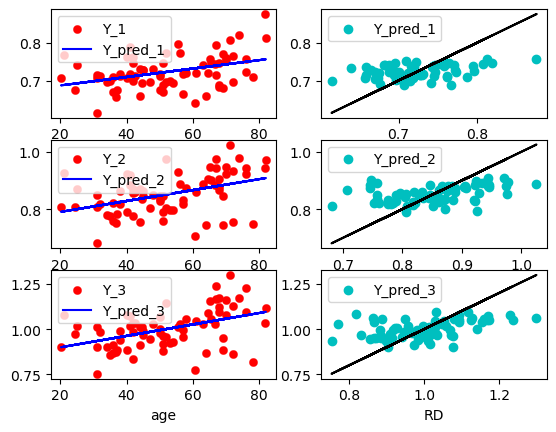

lh_V2_exvivo
Weights:
[[0.0010528]] [[0.00186723]] [[0.00345032]]
MSE:
0.0014015026453484821 0.0028434489420548913 0.006974017998200464
R2:
0.16023773328044688 0.2283020740123568 0.2917130023200455


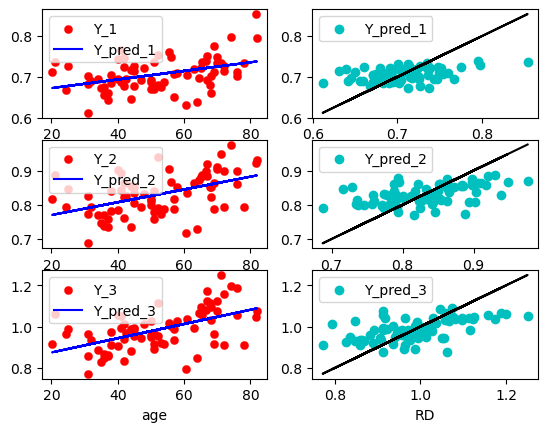

In [10]:
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y_1 = left_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = left_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = left_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    print('Weights:')
    print(weights_1, weights_2, weights_3)
    print('MSE:')
    print(mse_1, mse_2, mse_3)
    print('R2:')
    print(r2_1, r2_2, r2_3)
    plt.subplot(3, 2, 1)
    plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 2)
    plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
    plt.plot(Y_1[:,0], Y_1[:,0], color='k')
    plt.legend()
    plt.xlabel('RD')
    plt.subplot(3, 2, 3)
    plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 4)
    plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
    plt.plot(Y_2[:,0], Y_2[:,0], color='k')
    plt.legend()
    plt.xlabel('RD')
    plt.subplot(3, 2, 5)
    plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 6)
    plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
    plt.plot(Y_3[:,0], Y_3[:,0], color='k')
    plt.legend()
    plt.xlabel('RD')

    plt.show()


rh_BA1_exvivo_thresh
Weights:
[[-0.00112736]] [[-0.00105836]] [[-0.00017467]]
MSE:
0.001578477860818349 0.005666702692647003 0.016849579222226404
R2:
0.1626649233508708 0.045521646400640714 0.00043667212268927447


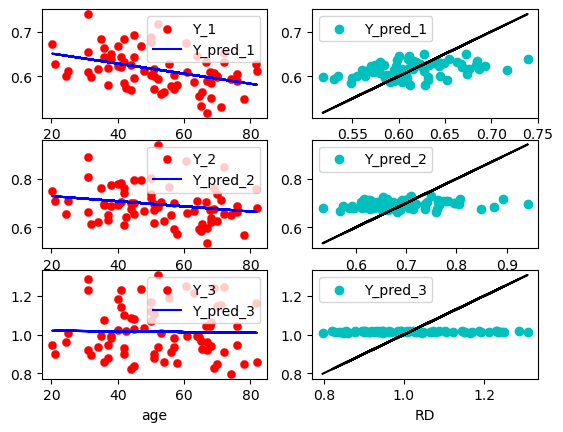

rh_BA1_exvivo
Weights:
[[-0.00072117]] [[-0.00021767]] [[0.0016095]]
MSE:
0.001634159585094737 0.0035692944171813548 0.005761812240702066
R2:
0.0713125311083812 0.003192633258555122 0.09786067598928427


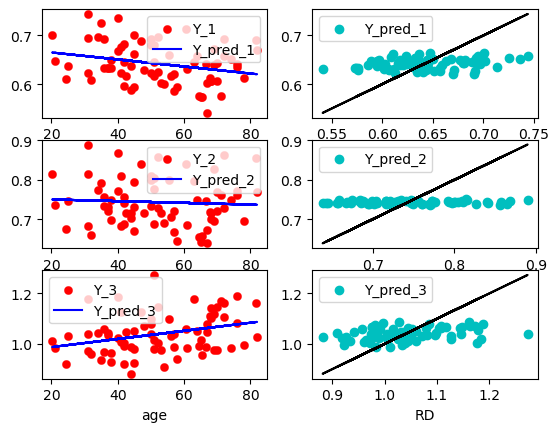

rh_BA2_exvivo_thresh
Weights:
[[-0.00021272]] [[0.00036689]] [[0.00290578]]
MSE:
0.0012928072795688687 0.0031002436404291953 0.019292757582857135
R2:
0.008374401190347602 0.010367181596834474 0.09550967559788459


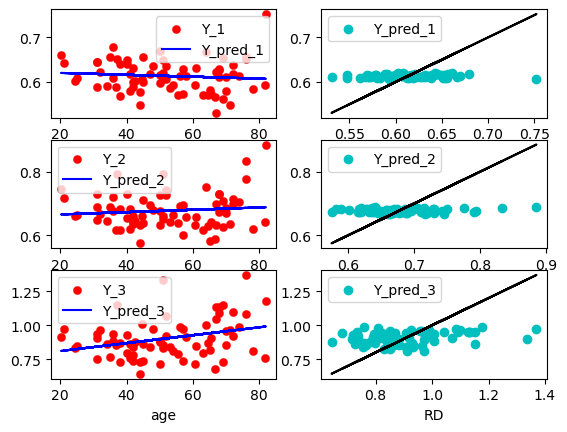

rh_BA2_exvivo
Weights:
[[-0.00050799]] [[7.57367754e-05]] [[0.00230824]]
MSE:
0.0012549990265647974 0.0025088625083433905 0.0050871245383558965
R2:
0.0472662349838725 0.0005513265560740388 0.20172289623230133


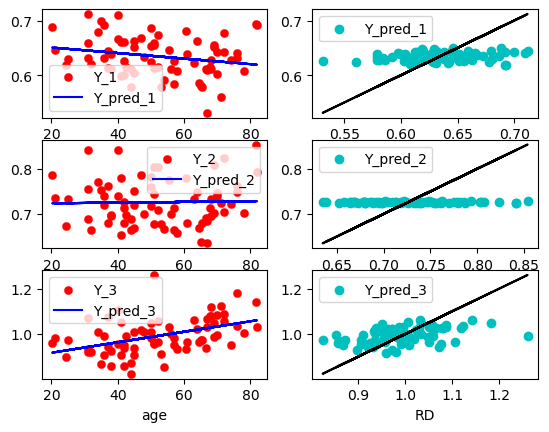

rh_BA3a_exvivo_thresh
Weights:
[[-0.00104245]] [[-0.00017075]] [[0.00306691]]
MSE:
0.002087577648763977 0.004785068419096746 0.011610340952247646
R2:
0.11158242070356106 0.0014679014191409934 0.16350547763405454


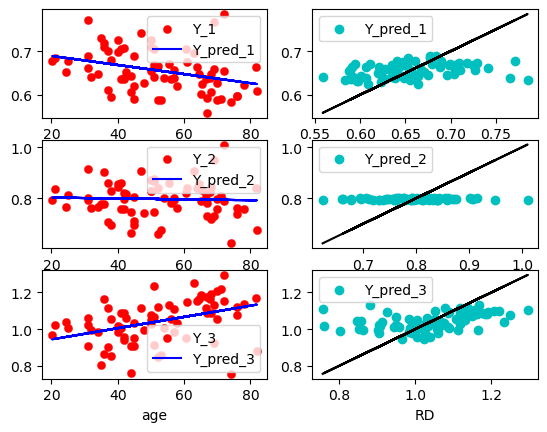

rh_BA3a_exvivo
Weights:
[[-0.0009016]] [[-8.03757771e-05]] [[0.00343369]]
MSE:
0.0026434511299371338 0.0047608720811354276 0.008274722254641816
R2:
0.06906903871590442 0.0003272904631188567 0.2558306332624285


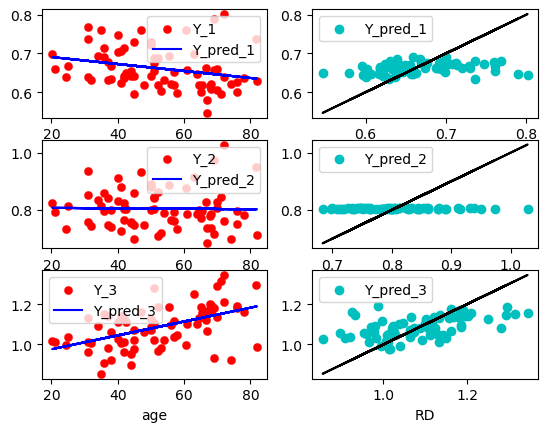

rh_BA3b_exvivo_thresh
Weights:
[[-0.00120028]] [[0.00031489]] [[0.00447268]]
MSE:
0.010358073554087624 0.0210666128007189 0.026255284210096257
R2:
0.03246880786959461 0.0011343564064631995 0.1552885264869236


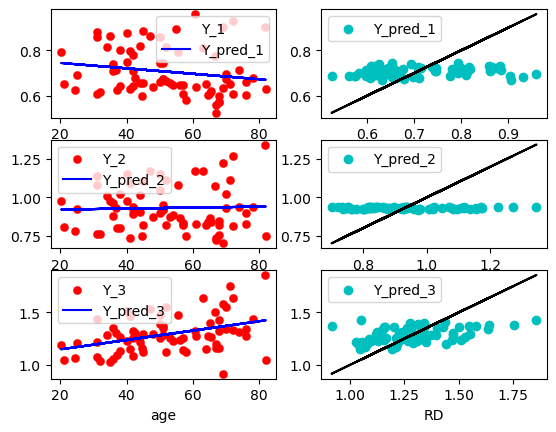

rh_BA3b_exvivo
Weights:
[[-0.00106581]] [[-9.7165554e-05]] [[0.00289966]]
MSE:
0.004333060883522084 0.009487856643821128 0.013889091178404842
R2:
0.05948958782383762 0.0002400291291043688 0.12744527625598012


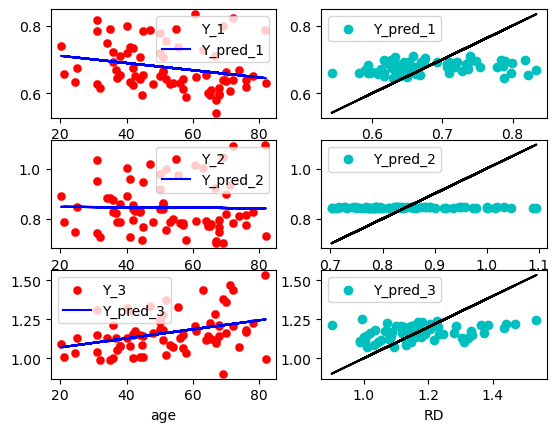

rh_BA4a_exvivo_thresh
Weights:
[[-0.00013504]] [[0.00035013]] [[0.00137712]]
MSE:
0.0013038986447107955 0.003162070147632435 0.007669456953333104
R2:
0.0033632313045990347 0.00926737733141103 0.05630184454879483


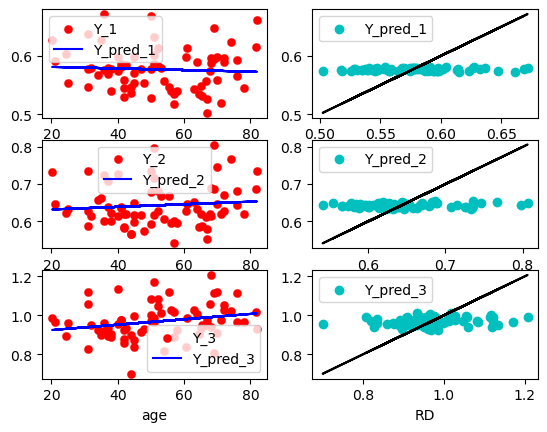

rh_BA4a_exvivo
Weights:
[[-0.00039059]] [[-0.0001412]] [[0.00235079]]
MSE:
0.0009786864935020195 0.0015464212535829603 0.007947205639094106
R2:
0.03624819225123721 0.00310091718749006 0.14366994848349102


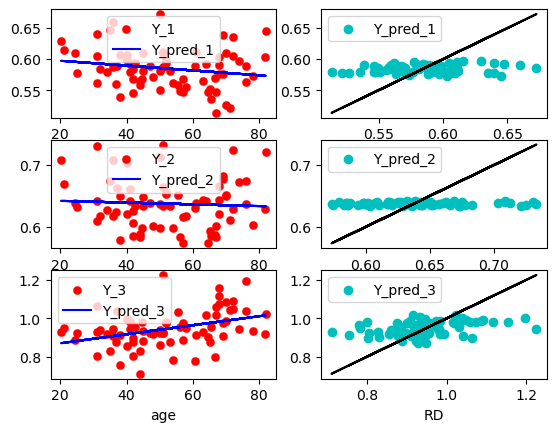

rh_BA4p_exvivo_thresh
Weights:
[[-0.0003944]] [[-0.00018436]] [[0.00448598]]
MSE:
0.0008523644525604036 0.0015051141569402825 0.01830663629169442
R2:
0.042173695857398164 0.005418743503922241 0.20962774875963686


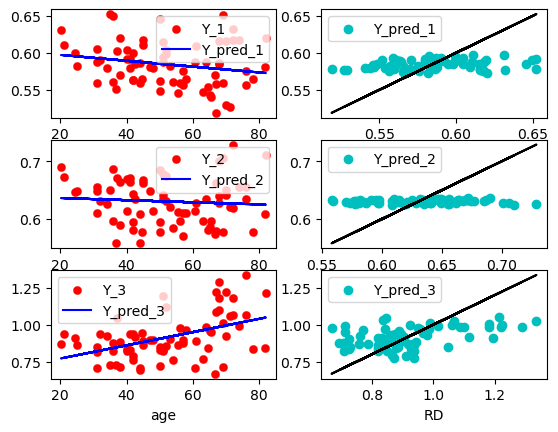

rh_BA4p_exvivo
Weights:
[[-0.00046178]] [[-7.28780448e-05]] [[0.00348667]]
MSE:
0.0008033329718253971 0.00126214747948518 0.011481438699023662
R2:
0.06019020698021049 0.0010142715937180302 0.20348493191269867


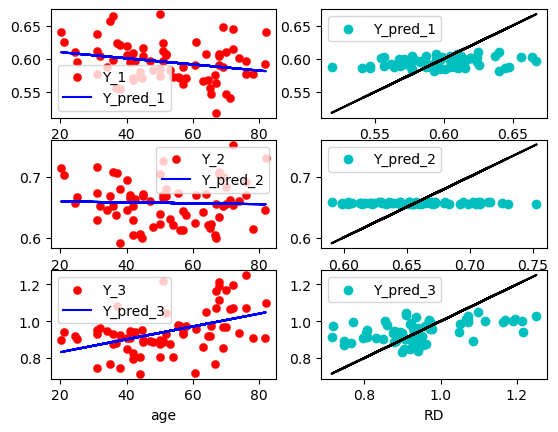

rh_BA6_exvivo_thresh
Weights:
[[-0.00056639]] [[-0.0004924]] [[0.00128345]]
MSE:
0.0009581482841968446 0.0016076170258168111 0.005600281238191014
R2:
0.07474315412474808 0.03511102700920532 0.06626511480699171


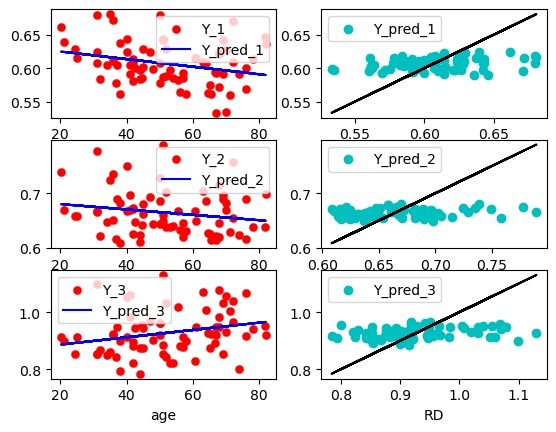

rh_BA6_exvivo
Weights:
[[-0.00048839]] [[-0.00019248]] [[0.00193656]]
MSE:
0.0008558408693812659 0.001320548222239098 0.00443553205720507
R2:
0.06300626344701565 0.006723475651055022 0.16943473846062695


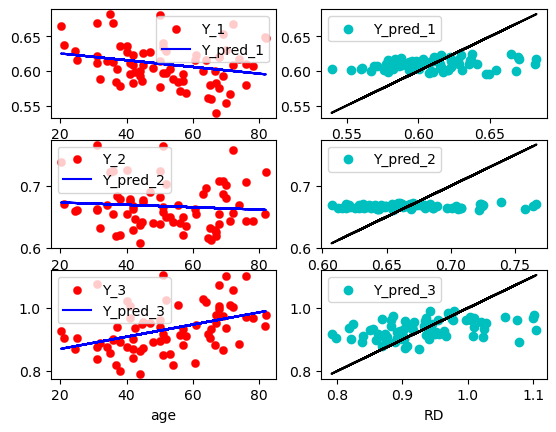

rh_BA44_exvivo_thresh
Weights:
[[6.6065971e-05]] [[0.00053954]] [[0.00239667]]
MSE:
0.0009137584356713144 0.0016389986465815273 0.004442606100055784
R2:
0.0011511599506844883 0.04109221072795022 0.2377783268449316


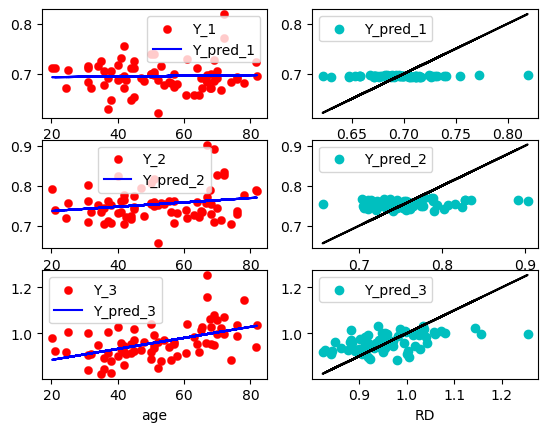

rh_BA44_exvivo
Weights:
[[-0.00014438]] [[0.00047571]] [[0.00337891]]
MSE:
0.0007456454995874791 0.0010200138750244018 0.0029794929226901333
R2:
0.006700096492332608 0.050810212337458305 0.48039415618172787


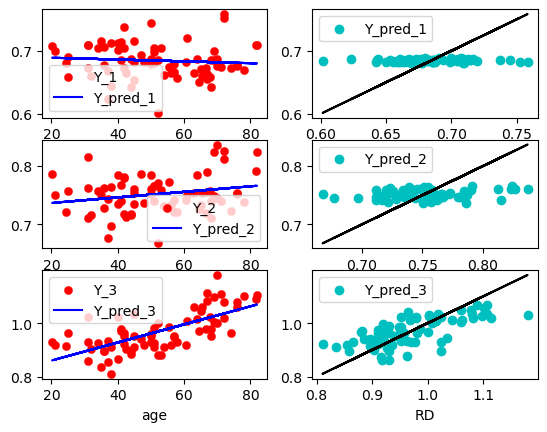

rh_BA45_exvivo_thresh
Weights:
[[1.31956813e-05]] [[0.00063359]] [[0.00316589]]
MSE:
0.0011025110604202188 0.0028369204351875047 0.008713875215803532
R2:
3.81044581082568e-05 0.03301430685081497 0.2172328617908863


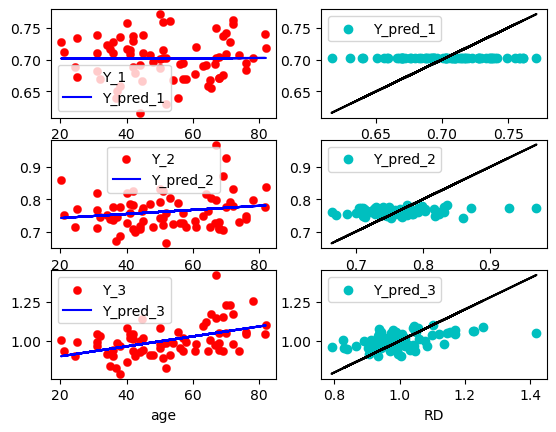

rh_BA45_exvivo
Weights:
[[0.00012385]] [[0.00061493]] [[0.00304397]]
MSE:
0.0007732722615511225 0.0012171113061584114 0.0036069024732274494
R2:
0.0047629524148817826 0.06973285559006126 0.38264371364861816


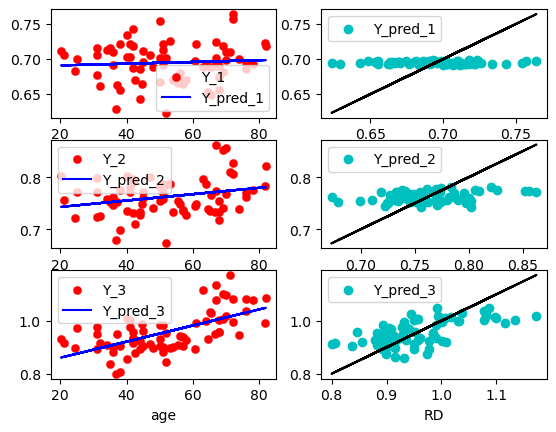

rh_cortex
Weights:
[[0.00021148]] [[0.00080306]] [[0.00320115]]
MSE:
0.0004603884770475481 0.0007083315631372571 0.001983291078521878
R2:
0.022902351657012265 0.18010451784871995 0.5548889463295543


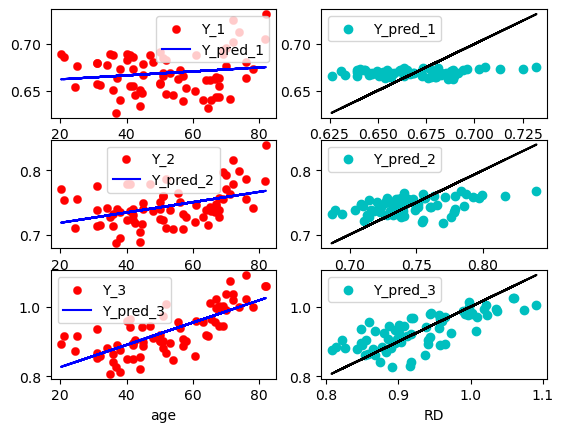

rh_cortex+hipamyg
Weights:
[[0.00020072]] [[0.00079183]] [[0.00317434]]
MSE:
0.00045361882260282107 0.0006955622246247787 0.0019392175161162008
R2:
0.020979881950645485 0.17863700689594486 0.5562837095114372


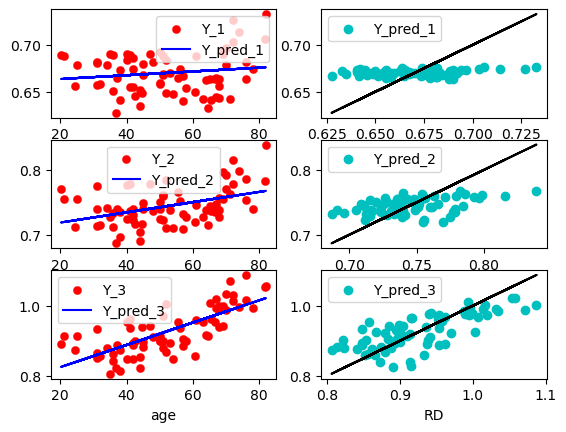

rh_entorhinal_exvivo_thresh
Weights:
[[0.00072012]] [[0.0015466]] [[0.00366229]]
MSE:
0.003021743955717982 0.0041081996530988995 0.006785332351310454
R2:
0.03975974695043716 0.12317698460428028 0.3229151092124741


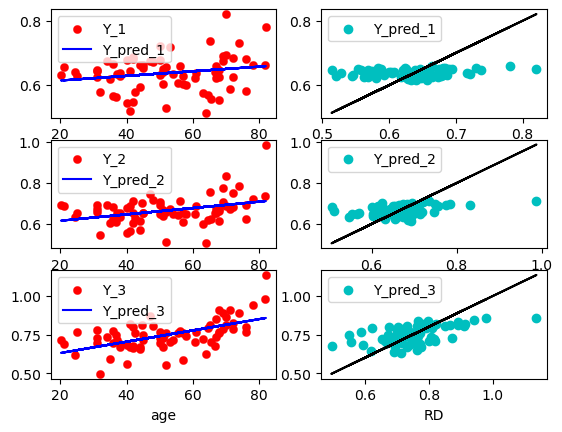

rh_entorhinal_exvivo
Weights:
[[0.00077692]] [[0.00156569]] [[0.00331836]]
MSE:
0.002410846715500528 0.003181758628627273 0.005394371660855353
R2:
0.05696663439136773 0.15675155178278732 0.329989455327073


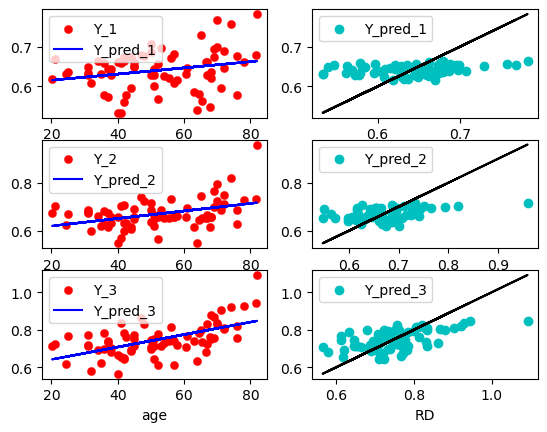

rh_FG1_mpm_vpnl
Weights:
[[0.00100452]] [[0.0023595]] [[0.00560838]]
MSE:
0.001885091151685385 0.003874497945082046 0.009607494827832417
R2:
0.11437861122424331 0.2574356018438494 0.4413119272939132


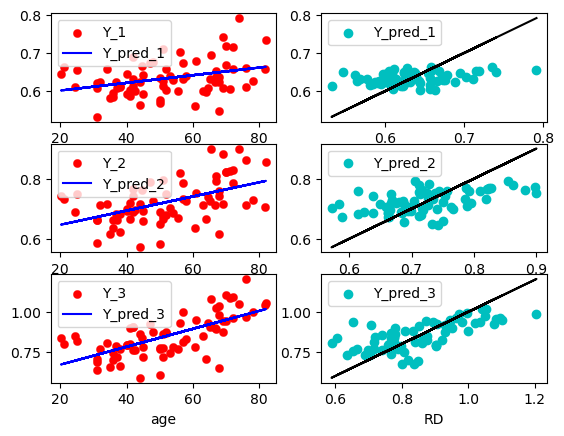

rh_FG2_mpm_vpnl
Weights:
[[0.00062272]] [[0.00161544]] [[0.00407096]]
MSE:
0.0011799196879209463 0.0022103369467780004 0.005625880158639776
R2:
0.07346865212506715 0.22170676396301892 0.41545957523537613


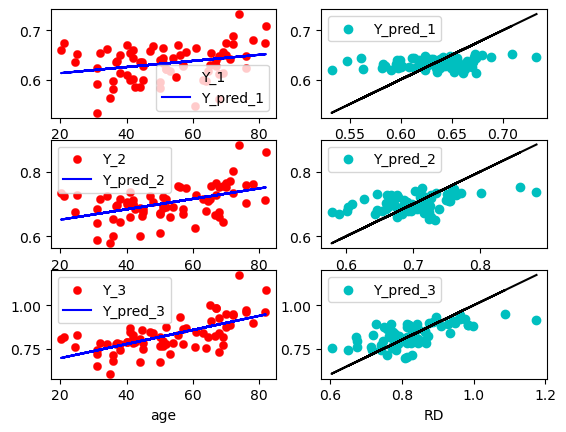

rh_FG3_mpm_vpnl
Weights:
[[0.00040142]] [[0.00176515]] [[0.00524054]]
MSE:
0.0011909510205929022 0.00230977199391275 0.00722854236770044
R2:
0.03161248724505861 0.24554855089510708 0.4782614827878956


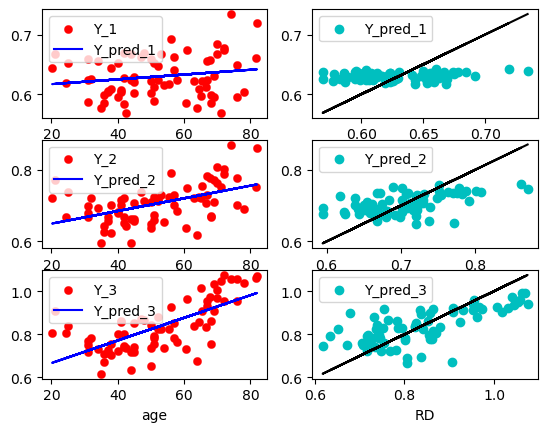

rh_FG4_mpm_vpnl
Weights:
[[0.00057453]] [[0.00113466]] [[0.00407554]]
MSE:
0.0010038491617544662 0.0016864487652476895 0.0053236006800570345
R2:
0.07350352967200169 0.15554220578202316 0.4294824614414462


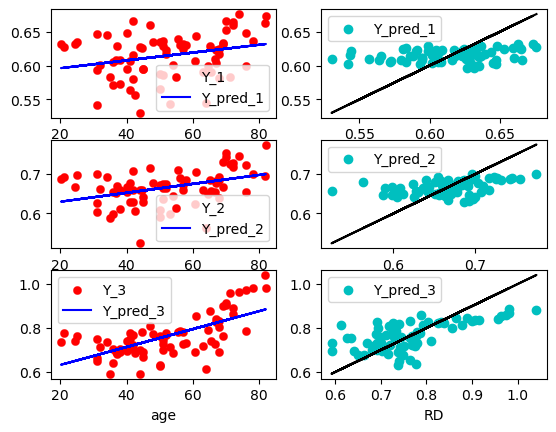

rh_hOc1_mpm_vpnl
Weights:
[[0.00118232]] [[0.00248379]] [[0.00445173]]
MSE:
0.0020256836265224966 0.003170862792713755 0.007455584281047227
R2:
0.14273299984935295 0.3194597222783031 0.39074184629042097


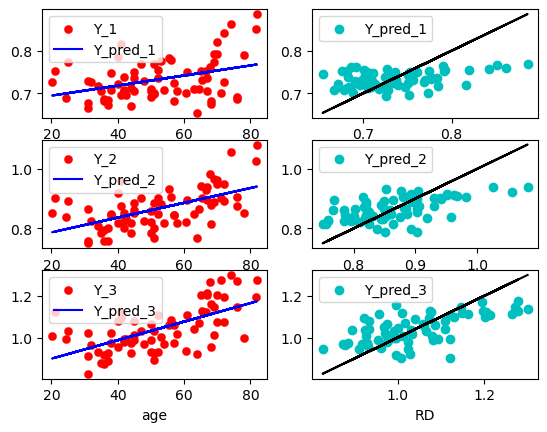

rh_hOc2_mpm_vpnl
Weights:
[[0.00066767]] [[0.00158814]] [[0.00356669]]
MSE:
0.0011423646206202818 0.003100456494722486 0.008126983041261629
R2:
0.08605033155426167 0.16407177149691277 0.27413666855147356


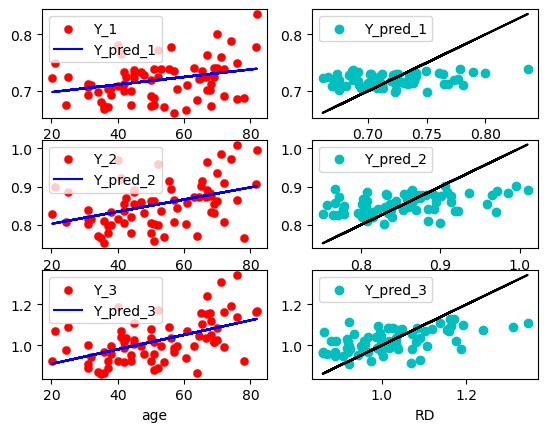

rh_hOc3v_mpm_vpnl
Weights:
[[0.00111343]] [[0.00195377]] [[0.0035354]]
MSE:
0.0018756175672766532 0.004069559604979445 0.010917109269366574
R2:
0.13753989491097185 0.1845485877009878 0.2164464726740397


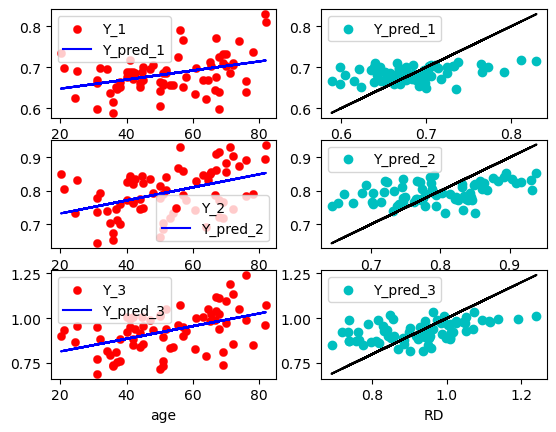

rh_hOc4v_mpm_vpnl
Weights:
[[0.00135635]] [[0.00218426]] [[0.0034527]]
MSE:
0.001888666724980142 0.0032298331233262443 0.010235625219966423
R2:
0.1902938516227144 0.26275572895429933 0.2193635070251797


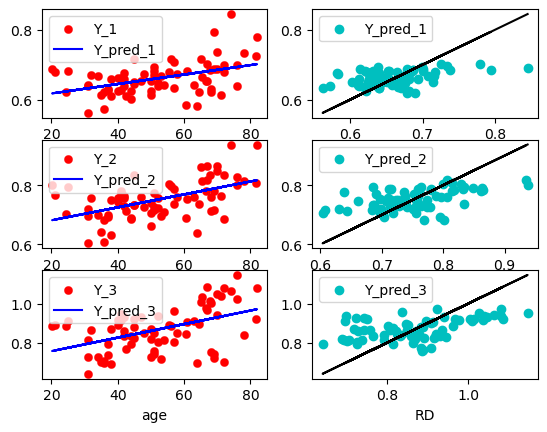

rh_MT_exvivo_thresh
Weights:
[[-0.000391]] [[0.00037893]] [[0.00433475]]
MSE:
0.001176788510327379 0.00419675268673852 0.015251247693773617
R2:
0.03039290456008137 0.008187193420007843 0.22914387108261913


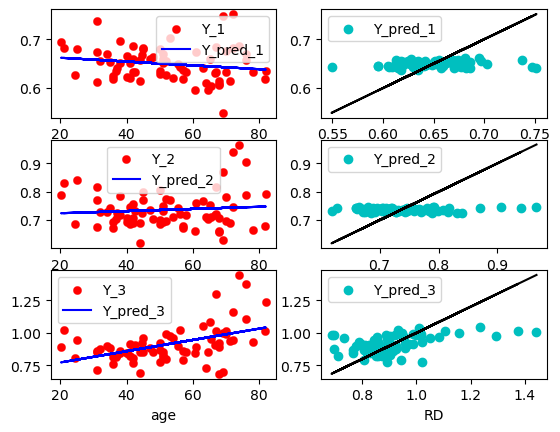

rh_MT_exvivo
Weights:
[[0.00019523]] [[0.00086754]] [[0.00375477]]
MSE:
0.000893542450587045 0.0014124391110076778 0.005654903836259763
R2:
0.010186694866520352 0.11391917605335233 0.37559487295187477


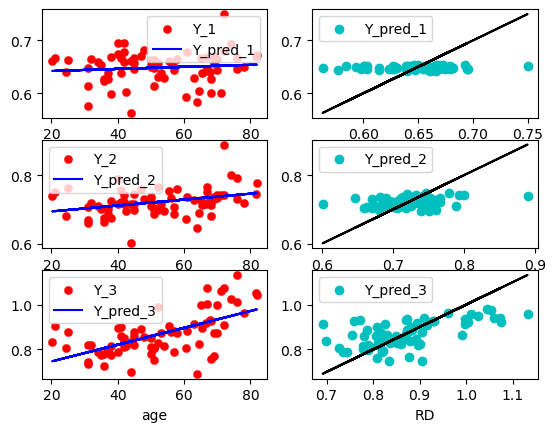

rh_nofix_cortex
Weights:
[[0.00050331]] [[0.00105781]] [[0.00329]]
MSE:
0.000532215723405894 0.0007815819919937638 0.001972283203816427
R2:
0.10301096337536553 0.25673892262886433 0.5697341553764534


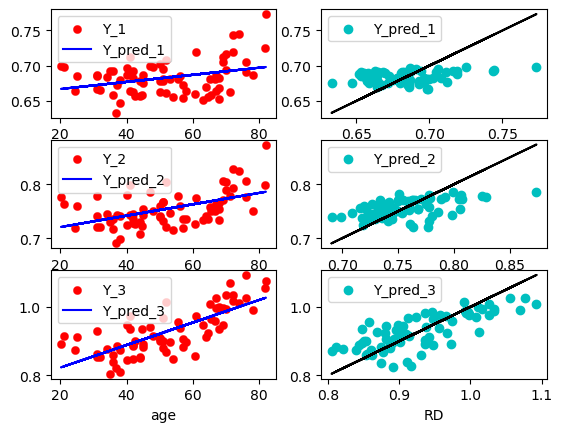

rh_perirhinal_exvivo_thresh
Weights:
[[0.00043915]] [[0.0009498]] [[0.00265701]]
MSE:
0.0030995362960186826 0.003052112393804732 0.003984659199257381
R2:
0.014790283123451653 0.06656658274033189 0.299460492467179


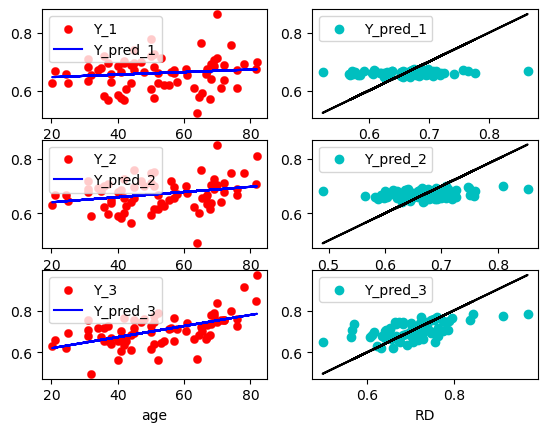

rh_perirhinal_exvivo
Weights:
[[0.00077337]] [[0.00126768]] [[0.00265899]]
MSE:
0.0027813729267268782 0.0032542648757821176 0.005009612505092762
R2:
0.049324520331750055 0.10646185862379198 0.2540198320037066


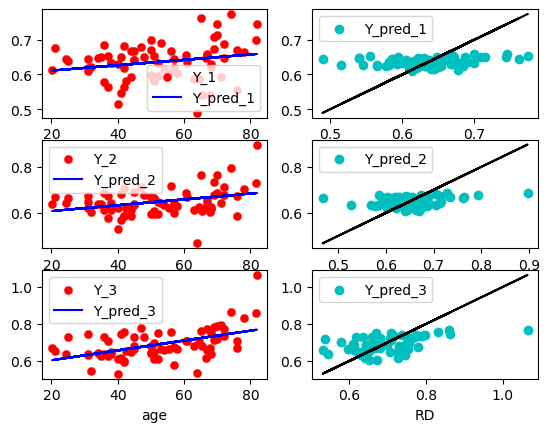

rh_V1_exvivo_thresh
Weights:
[[0.00123815]] [[0.00246849]] [[0.00433588]]
MSE:
0.002113724344674696 0.003281505405054299 0.007950355659650944
R2:
0.14892874404450118 0.30940336150751024 0.36327257566753524


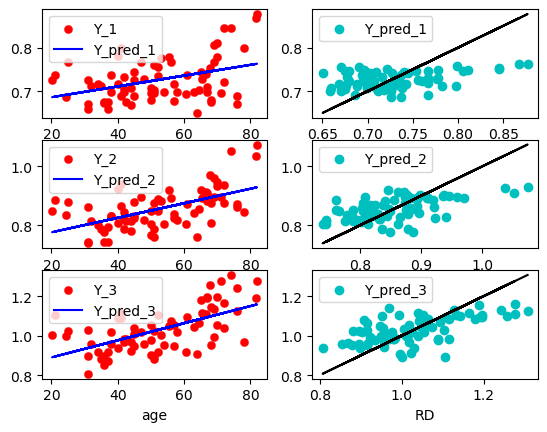

rh_V1_exvivo
Weights:
[[0.00107769]] [[0.00227375]] [[0.00412346]]
MSE:
0.0017031107431567096 0.0030871764515403707 0.007654667019948503
R2:
0.1412865419598227 0.28777434352294784 0.3489294136422917


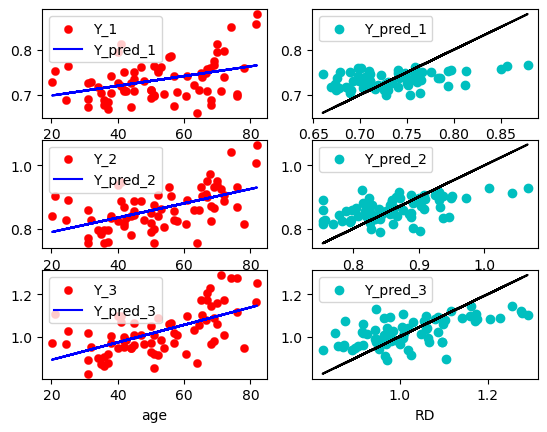

rh_V2_exvivo_thresh
Weights:
[[0.00089066]] [[0.00191165]] [[0.00386244]]
MSE:
0.001462690686342153 0.0036447893222666355 0.00816472621169588
R2:
0.115710751408585 0.19478943437619523 0.3059664161490606


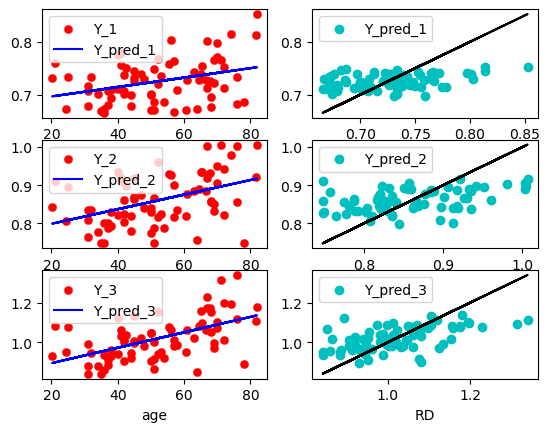

rh_V2_exvivo
Weights:
[[0.00089392]] [[0.00196096]] [[0.00405386]]
MSE:
0.0010689639193864871 0.002536701807117753 0.007021474597758059
R2:
0.15280324146921231 0.26779985946717144 0.3609010917455575


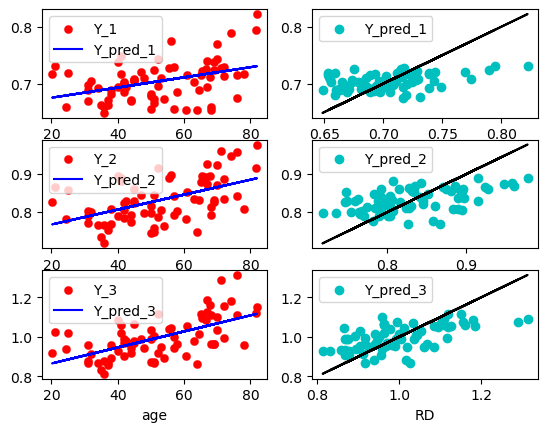

In [11]:
# For left hemisphere
for region in region_list:
    print('rh_' + region)
    Y_1 = right_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = right_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = right_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    print('Weights:')
    print(weights_1, weights_2, weights_3)
    print('MSE:')
    print(mse_1, mse_2, mse_3)
    print('R2:')
    print(r2_1, r2_2, r2_3)
    plt.subplot(3, 2, 1)
    plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 2)
    plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
    plt.plot(Y_1[:,0], Y_1[:,0], color='k')
    plt.legend()
    plt.xlabel('RD')
    plt.subplot(3, 2, 3)
    plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 4)
    plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
    plt.plot(Y_2[:,0], Y_2[:,0], color='k')
    plt.legend()
    plt.xlabel('RD')
    plt.subplot(3, 2, 5)
    plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 6)
    plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
    plt.plot(Y_3[:,0], Y_3[:,0], color='k')
    plt.legend()
    plt.xlabel('RD')

    plt.show()
